<center><img src="https://www.ifrax.it/scuola.png"></center>
<h1>Information Retrieval Project</h1>

Developed as part of the _Multimedia Information Retrieval and Computer Vision_ course (A.Y.2025-2026, prof. Nicola Tonellotto). Master's Degree in *Artificial Intelligence and Data Engineering* (School of Engineering, University of Pisa)

**» Group name**: `Rosenblatt` (in honour of Frank Rosenblatt, father of *Deep Learning*)

**» Authors of the project**: `Nilo Fabiano` `Gabriele Frassi` `Samuele Marchi` `Lorenzo Valtriani`

**» Description of the project**: The project consists in the implementation of an _Information Retrieval System_. The following blocks have been implented: dataset download (built using MSMARCO), Quasi-Succint Inverted Index construction and query processing (using an hybrid Python-C++ approach and Elias-Fano compression algorithm). Efficiency and effectiveness of the system are also evaluated.

# **0. Environment Setting**

## 0.1. Python Libraries
The first step is installing all the Python packages and libraries required in subsequent sections of this notebook. The imports are grouped to make it easier to understand how each library is used.

In [ ]:
import subprocess
import sys
from tqdm.auto import tqdm

# Installing necessary packages, avoiding lots of rows and show progresses in an elegant way
def packages_installation(packages):
    format = '{desc} {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}'
    description = "Installation (" + ", ".join(packages) + ")"

    pbar = tqdm(packages, total=len(packages), desc = description, bar_format = format)
    for package in pbar:
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", package],
                stdout = subprocess.DEVNULL, stderr = subprocess.PIPE
            )
        except subprocess.CalledProcessError as e:
            pbar.close()
            raise Exception(f"Error during the installation of package {package}")
    pbar.close()
    print("[DONE] Packages have been successfully installed", end="\n\n")

packages_installation(["ir_datasets", "PyStemmer", "pympler", "python-terrier", "ir_measures","pybind11"])

# Class Persistent_Storage ("0.3. Persistent storage using Pickle files and Google Drive")
import gdown, pickle, csv
from google.colab import drive

# Datasets management ("0.4 MSMARCO dataset" and all subsequent use of <documents, queries, qrels>)
import os, shutil, ir_datasets
from ir_datasets.formats import TsvDocs, TsvQueries, TrecQrels
from ir_datasets.datasets.base import Dataset

# Preprocessing ("1. Text Processing")
import nltk, regex, Stemmer
import pandas as pd
from nltk.corpus import stopwords
from functools import lru_cache

# Utilities
import heapq, string, time, humanize, math, statistics, jnius_config
from scipy import stats as st

# Data Structures & Analysis
import numpy as np
from pympler import asizeof
import collections
from collections import Counter, defaultdict
from bisect import bisect_left
from typing import List, Tuple, Dict

# Evaluation ("5. Evaluate the Effectiveness", "6. Comparison with PyTerrier" and "7. Significance testing")
import pyterrier as pt
import ir_measures
import psutil
import random

print("[DONE] Libraries have been successfully imported!", end="\n\n")

# Installation of Github's repository "SDSL - Succinct Data Structure Library"
def repository_installation():
  print("[INFO] SDSL - Succinct Data Structure Library (simongog) is going to be installed")

  !git clone -q https://github.com/simongog/sdsl-lite.git
  ! cd sdsl-lite && CXXFLAGS="-O3 -fPIC -w" ./install.sh /usr/local > /dev/null 2>&1

  print("[DONE] SDSL - Succinct Data Structure Library (simongog) has been successfully installed")

repository_installation()

Installation (ir_datasets, PyStemmer, pympler, python-terrier, ir_measures, pybind11)   0%|          | 0/6

[DONE] Packages have been successfully installed

[DONE] Libraries have been successfully imported!

[INFO] SDSL - Succinct Data Structure Library (simongog) is going to be installed
fatal: destination path 'sdsl-lite' already exists and is not an empty directory.
[DONE] SDSL - Succinct Data Structure Library (simongog) has been successfully installed


## 0.2. Utility function: Profile decorator
The `profile` decorator is a utility designed to monitor performance by measuring a function's execution time. Instead of returning raw seconds, it formats the duration into a human-readable string.

```
@profile
def function_name(function_variables) :
```

In [ ]:
def profile(f):
    def f_timer(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        elapsed = end - start

        if elapsed < 60:
            time_str = f"{elapsed:.3f}s"
        elif elapsed < 3600:
            minutes = int(elapsed // 60)
            seconds = elapsed % 60
            time_str = f"{minutes}m {seconds:.3f}s"
        else:
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = elapsed % 60
            time_str = f"{hours}h {minutes}m {seconds:.3f}s"

        print(f"{f.__name__} ({time_str})")
        return result
    return f_timer

## 0.3. Persistent storage using Pickle files and Google Drive
To streamline notebook analysis and avoid executing time-consuming functions, we implemented the `Persistent_Storage` class, which allows to save data structures in a persistent way using *Pickle files*. Indeed Google Colab cleans main and disk memory when refreshed.

A special method for saving *run files* is also defined (`save_run_file`). The `get_base_path` method ensures consistent path in all *load* and *save* operations outside the class.

Two possible operational modes are available (chosen during the instantiation of the class):
- **Drive mode**, _adopted by project group members_.
  
  Let Google Colab connects to the user Google Drive to allow saving data structures in a persistent and shared enviroment with `save_data_structure` and `save_run_file` methods.  Data structures can be retrieved in future executions with `load_data_structure` method, avoiding to execute the most time-consuming code blocks.

- **Non-Drive mode**, _adopted by external users_ (e.g. prof. Tonellotto).

  Downloads a directory with pre-processed data structures into the local Colab disk. Methods `save_data_structure`, `save_run_file` and `load_data_structure` will use as target the disk memory. So refreshing the environment will cause to lost all progress. The directory contains data structures generated from the most time-consuming code blocks.

In [ ]:
class Persistent_Storage:
  def __init__(self, drive_mode = False):
    self.__drive_mode = drive_mode

    # Drive mode (True) vs Non-Drive mode (False)
    if self.__drive_mode:
      drive.mount('/content/drive', force_remount = True)

      self.__base_path = os.path.join('/content/drive','MyDrive','Progetto Multimedia Information','IR')
    else:
      url = 'https://drive.google.com/drive/folders/1P1EFkcYaltTfQP30SbfGvHD0fYbawZSl?usp=sharing'
      gdown.download_folder(url, quiet = False, use_cookies = False)

      self.__base_path = os.path.join('/content','IR')

    print(end = "\n\n")
    print("[INFO] Base path: ", self.__base_path)

  def get_base_path(self): # Returns private variable base_path
    return self.__base_path

  def get_drive_mode(self): # Returns private variable drive_mode
    return self.__drive_mode

  ######################################################
  ############## METHODS FOR PICKLE FILES ##############
  ######################################################

  def save_data_structures(self, data_dict): # Dealing with more data structures in an elegant way
    for name, ds in data_dict.items():
      self.save_data_structure(ds, name)

  def load_data_structures(self, names_list): # Dealing with more data structures in an elegant way
    return [self.load_data_structure(name) for name in names_list]

  @profile
  def save_data_structure(self, ds, name):
    os.makedirs(self.__base_path, exist_ok = True) # Creation of dirs (if necessary)

    # Write operation
    with open(os.path.join(self.__base_path, f"{name}.pickle"), 'wb') as f:
        pickle.dump(ds, f)

    print(f"[DONE] Data structure {name} saved to {self.__base_path}")

  @profile
  def load_data_structure(self, name):
    # Read operation
    with open(os.path.join(self.__base_path, f"{name}.pickle"), 'rb') as f:
        ds = pickle.load(f)

    print(f"[DONE] Data structure {name} loaded from {self.__base_path}")
    return ds

  ###################################################
  ############## METHODS FOR RUN FILES ##############
  ###################################################

  def save_run_file(self, ds, run_id):
    # Saving result as table using pandas
    run_df = pd.DataFrame(ds, columns=["query_id", "Q0", "doc_id", "rank", "score", "run_name"])

    # Save in TREC format in .txt (tab-separated, no header, no index)
    run_df.to_csv(os.path.join(self.__base_path, f"{run_id}.txt"), sep='\t', header=False, index=False)

    print(f"[DONE] RUN file {run_id}.txt has been saved")

persistent_storage = Persistent_Storage(drive_mode = False)

Retrieving folder contents


Retrieving folder 1CYl_CRKi1TyMN0UyBJJAdrZsMYGUsv4k dataset
Processing file 1e4OsQd9iHIQlLFGG32wQxNLrNbjAmaQ6 2019qrels-pass.txt
Processing file 1iDazmgPDiMphpJwx7eXj7QovJVCWCKEY 2020qrels-pass.txt
Processing file 1F33D7rvdxwaIIHE6mqsy9UM7insFuG0Z collection.tar.gz
Processing file 1UTA9y8JdybLJUXXzhO7alT91EabD03SV msmarco-test2019-queries.tsv.gz
Processing file 143Gp2H03nxMTHQDzbFslYcfHnSYenIoG msmarco-test2020-queries.tsv.gz
Processing file 1R2hmoWusUiFRdcufuzx0pyI_xVfEjhZT doc_t.pickle
Processing file 1COHfK6xhTOREN29z11r0Dd77APbsZLWy inv_t.pickle
Processing file 1L1NmmAK_tasyXKp1rrBNPgXMdFjzs97w invertedIndexFile.bin
Processing file 1IWE3-1-m0svv4FO9EypsqzIcISBYW-7r lex_t.pickle
Processing file 1zP8UIv3ovelr1ULT9cOp94VHG6vb6gIi maxScores.pickle
Processing file 1FoNuGfrxgxAiGUVPSYsVgRCu1DCaW1q3 PyTerrier_bm25.txt
Processing file 1sn0SNoGQeFlrOXkkliH6ceErl2Q4V_JO stats_t.pickle
Processing file 15ShstJzm7SW1ZLsv1_vFUnmDMTPJ-szM WAND_bm25.txt
Processing file 1-g4lC5xM7BEtc7TNd9rPF8dpflp

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1e4OsQd9iHIQlLFGG32wQxNLrNbjAmaQ6
To: /content/IR/dataset/2019qrels-pass.txt
100%|██████████| 187k/187k [00:00<00:00, 12.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iDazmgPDiMphpJwx7eXj7QovJVCWCKEY
To: /content/IR/dataset/2020qrels-pass.txt
100%|██████████| 219k/219k [00:00<00:00, 28.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1F33D7rvdxwaIIHE6mqsy9UM7insFuG0Z
From (redirected): https://drive.google.com/uc?id=1F33D7rvdxwaIIHE6mqsy9UM7insFuG0Z&confirm=t&uuid=08c1afcf-3a23-46a8-b209-111c86ec1870
To: /content/IR/dataset/collection.tar.gz
100%|██████████| 1.04G/1.04G [00:11<00:00, 92.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UTA9y8JdybLJUXXzhO7alT91EabD03SV
To: /content/IR/dataset/msmarco-test2019-queries.tsv.gz
100%|██████████| 4.28k/4.28k [00:00<00:00, 10.9MB/s]
Downloading.



[INFO] Base path:  /content/IR



Download completed


## 0.4. MSMARCO dataset

### 0.4.1. Adoption and Cranfield Paradigm

MSMARCO is one of the best known datasets in Information Retrieval. It's an experimental benchmark that enables evaluation of IR systems not only in terms of _efficiency_ but, more importantly, _effectiveness_, following the principles of the _Cranfield Paradigm_.

We have adopted the MSMARCO dataset for the following reasons:
- MSMARCO is an experimental benchmark developed independently of any IR system: this is essential to allow *comparability* among systems and *repeatability* of the experiment, while also avoiding any type of bias.
- MSMARCO is one of the biggest datasets available in the research community. It consists of 3.2 million English documents and 8.8 million passages.
- MSMARCO is also a _real-world based dataset_: its queries come from Bing's search query logs

<u>Expansion of queries and qrels</u>. The _corpus_ consists of the _passages_ from the 2019 version, while _queries_ and _qrels_ were created by merging the official sets from both the 2019 and 2020 versions. This allows expansion of the experimental benchmark and more statistically relevant results.

### 0.4.2. Database setup

The function `build_dataset` creates the dataset. It takes as input an instance of the `Persistent_Storage` class and the specific storage's folder where MSMARCO _passages_, _queries_ and _qrels_ are stored after download. The `Persistent_Storage` class has already handled download of relevant data structures during its instantiation.

The function's workflow involves:
1. decompressing `tar.gz` and `tsv.gz` files (with MSMARCO _passages_, _queries_ and _qrels_);
2. consolidating _queries_ and _qrels_ into unified files
3. loading the resulting dataset into the `ir_datasets` library.

The function returns a `ir_datasets.Dataset` object, which we will use in subsequent code blocks to access the contents of the dataset. The `LocalFile` class is a wrapper for `TsvDocs`, `TsvQueries` and `TrecQrels` functions, which invoke `path` and `stream` methods on input objects.

In [ ]:
@profile
def build_dataset(persistent_storage, folder):
    ######### 0.1. UTILITY FUNCTIONS AND CLASSES
    def concatenate_files(base_dir, output_file, input_files):
      with open(os.path.join(base_dir, output_file), 'wb') as outfile:
        for fname in input_files:
          with open(os.path.join(base_dir, fname), 'rb') as infile:
            shutil.copyfileobj(infile, outfile)

    class LocalFile:
      def __init__(self, path):
          self._path = os.path.abspath(path)
      def path(self, force=True):
          return self._path
      def stream(self):
          # TsvDocs e simili si aspettano un file binario (come .gz)
          return open(self._path, "rb")

    print("FUNCTION build_dataset:")

    ######### 0.2. DEFINE PATH
    base_dir = os.path.join(persistent_storage.get_base_path(), folder) # dataset root folder

    ######## 1. DECOMPRESSION OF tar.gz AND tsv.gz FILES
    print("[1] Files decompression (collection.tar.gz, msmarco-test2019-queries.tsv.gz, msmarco-test2020-queries.tsv.gz)")
    subprocess.run(["tar", "-xf", "collection.tar.gz"], cwd = base_dir, check=True)
    subprocess.run(["gzip", "-dk", "-f", "msmarco-test2019-queries.tsv.gz"], cwd = base_dir, check = True)
    subprocess.run(["gzip", "-dk", "-f", "msmarco-test2020-queries.tsv.gz"], cwd = base_dir, check = True)

    ######## 2. CONCATENATION OF QRELS AND QUERIES AND CREATION OF UNIFIED FILES
    print("[2] qrels concatenation (2019 and 2020) into all_qrels.txt")
    concatenate_files(base_dir, "all_qrels.txt", ["2019qrels-pass.txt", "2020qrels-pass.txt"])

    print("[3] queries concatenation (2019 and 2020) into all_queries.tsv")
    concatenate_files(base_dir, "all_queries.tsv", ["msmarco-test2019-queries.tsv", "msmarco-test2020-queries.tsv"])

    print("    [INFO] Uncompressed and concatenated files here:", base_dir)

    ######## 3. CREATION OF "local-msmarco/dl201920" dataset within ir_datasets
    print("[4] Creation of \"local-msmarco/dl201920\" dataset within ir_datasets")

    if hasattr(ir_datasets.registry, '_registered'): # Avoiding exceptions in case of multiple executions of this function
      ir_datasets.registry._registered.clear()
      print("    [INFO] ir_datasets registry cleared")

    collection_file = os.path.join(base_dir, "collection.tsv") # Document collection
    qrels_file = os.path.join(base_dir, "all_qrels.txt") # Concatenated qrels
    queries_file = os.path.join(base_dir, "all_queries.tsv") # Concatenated queries

    docs = TsvDocs(LocalFile(collection_file), namespace="msmarco_dl201920", lang="en")
    queries = TsvQueries(LocalFile(queries_file), namespace="msmarco_dl201920", lang="en")
    qrels = TrecQrels(LocalFile(qrels_file), {0: "not relevant", 1: "relevant"})
    ir_datasets.registry.register("local-msmarco/dl201920", Dataset(docs, queries, qrels))

    ds = ir_datasets.load("local-msmarco/dl201920")

    print("[DONE] Dataset successfully generated")

    num_documents = sum(1 for _ in open(collection_file, 'r'))
    num_queries = sum(1 for _ in open(queries_file, 'r'))
    num_qrels = sum(1 for _ in open(qrels_file, 'r'))

    return ds, {"documents": num_documents, "queries": num_queries, "qrels": num_qrels}

ds, stats_dataset = build_dataset(persistent_storage, "dataset")

FUNCTION build_dataset:
[1] Files decompression (collection.tar.gz, msmarco-test2019-queries.tsv.gz, msmarco-test2020-queries.tsv.gz)
[2] qrels concatenation (2019 and 2020) into all_qrels.txt
[3] queries concatenation (2019 and 2020) into all_queries.tsv
    [INFO] Uncompressed and concatenated files here: /content/IR/dataset
[4] Creation of "local-msmarco/dl201920" dataset within ir_datasets
    [INFO] ir_datasets registry cleared
[DONE] Dataset successfully generated
build_dataset (51.717s)


We have:

In [ ]:
print(f"Number of documents (passages): {stats_dataset['documents']}")
print(f"Number of queries: {stats_dataset['queries']}")
print(f"Number of qrels: {stats_dataset['qrels']}")

Number of documents (passages): 8841823
Number of queries: 400
Number of qrels: 20646


# **1. Text Processing**

## 1.1. Preprocessor class

The `Preprocessor` class is the engine for text processing:
- It is instantiated only once, before processing the first string: the constructor initializes the necessary data structures (with focus on the English language).
- It emulates a _callable object_: after the class is instantiated, it can be called as a function (thanks to the `__call__` special method). The function takes a string as input and returns a vector with stemmed tokens.
```
preprocessing = Preprocessor()
tokens  = preprocessing("This is a string")                               # Example of call
tokens2 = preprocessing("Thank you for your attention to this matter")    # Example of call
tokens3 = preprocessing("Despite the constant negative press covfefe")    # Example of call
```

The function's workflow consists of the following steps:
1. **Tokenization by means of _Regular Expressions_**.

    We utilize Regular Expressions to perform tokenization, thus extracting tokens that match specific patterns. The most common patterns in our RegExp are the following ones:
    
    - tokens consisting exclusively of alphabetic characters;
    - tokens consisting exclusively of numeric digits.
    
    We additionally introduce patterns for more peculiar tokens:

    - **Hyphenated words,  Contractions, Acronyms and Abbreviations** (`[-.'][a-z]+`).
    
      Patterns like _well-known_, _rock'n'roll_, _it's_ are preserved as single tokens. Strings such as `e.g.` or `u.s.a.` are correctly tokenized. The RegExp is able to catch acronyms and abbreviations of different lengths. We're able to find more complex words, while also preserving essential parts of the English language.

    - **Version Numbers and IP Addresses** (`(?:\.\d+)*`).
    
      By allowing repeated patterns of dots followed by digits (e.g., _1.2.1_ or _192.168.1.1_), we preserve technical identifiers.

    - **Alphanumeric Identifiers** (`[-.]?\d+`).
    
      It captures codes where letters are followed by numbers, such as `iPhone13` or `Agent007`.

    - **Ordinal Numbers and Measurements** (`[a-z]+`).
    
      It captures sequences like _1st_, _2nd_, or _50mg_ by allowing an alphabetic suffix to follow the leading digits.
      
    

2. **Removal of stopwords**.

    Tokens are reduced by removing _stop words_, that is, the most frequent words. This removes words that are irrelevant to specific queries while significantly decreasing the overall size of the Inverted Index. A _stop words_ set is defined during instantiation of the class, using download function for _NLTK Corpora_ (a collection of linguistic data).

3. **Stemming operations applied to each token**.

    Each token is stemmed using _Snowball Algorithm_, a variant of _Porter_. Stemming requires a careful balance between output quality and execution speed, as it's a significant overhead in text processing.
    For this reason, we utilize the implementation proposed by the `PyStemmer` package, which is significantly faster than other ones (e.g. `nltk`).

In [ ]:
class Preprocessor:
    def __init__(self, cache_size = None, do_stemming = True):
      # STOPWORDS
      nltk.download('stopwords', quiet=True)
      self.__stop_words = set(stopwords.words('english'))

      # STEMMER
      self.__do_stemming = do_stemming

      if self.__do_stemming == True :
          self.__stemmer = Stemmer.Stemmer('english')
          if cache_size is None:
              self.stemming_function = self.__stemmer.stemWord
          else:
              self.stemming_function = lru_cache(maxsize=cache_size)(self.__stemmer.stemWord)

      # REGEX
      regex.purge()
      self.__token_pattern = regex.compile(r'''
            (?:
                # PRIMO PASSAGGIO: TOKENS CHE INIZIANO CON SEQUENZE DI CARATTERI
                [a-z]+
                (?:
                    [-.'][a-z]+                  # Trattino/punto/apostrofo + lettere
                    |
                    [-.]?\d+                     # Numero con prefisso opzionale
                )*

                |                                 # OPPURE

                # SECONDO PASSAGGIO: TOKEN CHE INIZIANO CON CIFRE NUMERICHE
                \d+                              # Parte numerica iniziale (es. 1, 10, 100)
                (?:
                    (?:\.\d+)*                    # Caso A: Uno o più decimali (.1.2.3)
                    |                             # OPPURE
                    [a-z]+                        # Caso B: Suffisso alfabetico (st, nd, rd)
                )?
            )
          ''', regex.VERBOSE)

    def __call__(self, text):
      tokens = self.__token_pattern.findall(text.lower())

      stop_words = self.__stop_words

      if self.__do_stemming == True :
        stemming_function = self.stemming_function
        filtered_tokens = [stemming_function(t) for t in tokens if t not in stop_words]
      else :
        filtered_tokens = [t for t in tokens if t not in stop_words]

      return filtered_tokens

## 1.2 Zipf's and Heap's law: size of the cache

While PyStemmer offers a significantly faster implementation rather than the Snowball algorithm, it still account for a significant portion of the computational load. We further reduce it by adopting a LRU cache (_Least Recently Used_ cache, the simplest type in order to minimize the overhead).

The `Preprocessor` class, introduced in *1.1. Preprocessor class*, includes a `cache_size` parameter that defines the maximum number of elements the cache can store. We know two laws: _Heap's Law_ and _Zipf's Law_.
- **Heap's Law**

  The Heap's law expresses the vocabulary size $|V|$ of a collection of documents (i.e. the total number of distinct tokens) as a function of collection size $N$ (number of tokens). This estimate of the vocabulary size is expressed as:

  $$|V| = k N^\beta$$

  where $N$ is the total number of tokens in the collection. $k,\beta$ are constants that are dependent on the document collection. Typical values: $\beta \approx 0.5, 30 \leq k \leq 100$.

- **Zipf's Law**

  The Zipf's law states that the $i$-th most frequent term has a collection frequency $\propto 1/i$. We're representing the $i$-th collection frequency as $\text{cf}_i=\frac{K}{i}$, where $K$ is a normalization constant.

Let's try to determine a possible size by analysing a representative subset of MSMARCO passages. We'll use the class `IncrementalStats`, which stores necessary information in the internal variables. The stemming operations are temporarily disabled: remember that non-stemmed tokens are the input, thus we must consider the evolution of non-stemmed tokens.



In [ ]:
class DocumentStats:
    def __init__(self, c_preprocessing_function):
        self.word_counts = collections.Counter()
        self.vocab_lengths = []      # |V| (y axis)
        self.collection_lengths = [] # N (x axis)
        self.total_tokens = 0        # Counter N

        self.documents_counter = 0;

        self.preprocessing_function = c_preprocessing_function

    def add_document(self, text):
        # Preprocessing
        tokens = self.preprocessing_function(text)
        if not tokens:
            return

        # Update lexicon
        self.word_counts.update(tokens)

        # Total number of tokens
        self.total_tokens += len(tokens)

        # Update N
        self.collection_lengths.append(self.total_tokens)

        # Update |V|
        self.vocab_lengths.append(len(self.word_counts))

        self.documents_counter = self.documents_counter + 1

        return text

    def get_results(self):
        sorted_frequencies = np.array(sorted(self.word_counts.values(), reverse=True))
        return sorted_frequencies, self.vocab_lengths, self.collection_lengths, self.total_tokens/self.documents_counter

# Instance of the Preprocessor class without caching and without stemming
# - The size of the cache depends on non-stemmed values
# - We're not considering stopwords because they're not considered by the stemming function
preprocessing_test = Preprocessor(cache_size = None, do_stemming = False)
stats_collector = DocumentStats(preprocessing_test)

random.seed(37) # Repeatability of the experiment
sampled_indexes = set(random.sample(range(stats_dataset['documents']), 100000)) # Random choice in order to avoid any form of bias
passages = [stats_collector.add_document(doc.text) for i, doc in enumerate(ds.docs_iter()) if i in sampled_indexes]

frequencies, vocab_lengths, collection_lengths, average_tokens = stats_collector.get_results()

Let's apply these two laws:

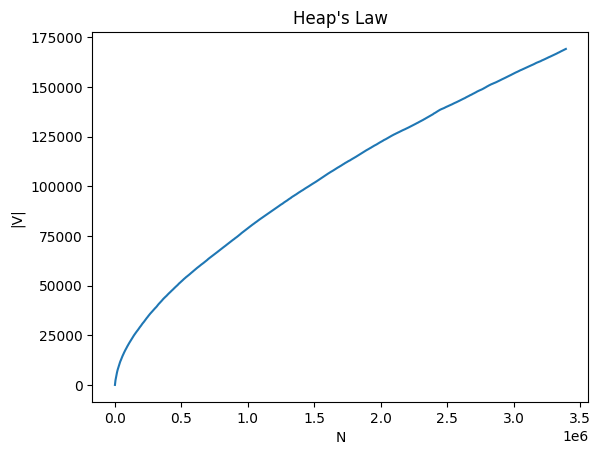

--- Heap's Law constants ---
Beta: 0.6118, k:  17.0208

Average number of non-stemmed tokens: 33
Prediction: We'll have 2612884 unique terms with 300094920 non-stemmed tokens


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

##########################################
########## Heap's law plot
##########################################
plt.figure()

plt.plot(collection_lengths, vocab_lengths)
plt.xlabel('N')
plt.ylabel('|V|')
plt.title("Heap's Law")
plt.show()

##########################################
########## FINDING beta AND K values
##########################################
log_N = np.log(collection_lengths) # Logarithmic transformation of Heap's Law
log_V = np.log(vocab_lengths)

# esegue una regressione lineare usando log_N come asse X, log_V come asse Y e cercando un polinomio di primo grado (y=mx+q, dove beta=m e log_k=q)
beta, log_k = np.polyfit(log_N, log_V, 1)
k = np.exp(log_k)

print(f"--- Heap's Law constants ---")
print(f"Beta: {beta:.4f}, k:  {k:.4f}\n")

########################################################
########## Estimating size of V by applying Heap's law
########################################################

# "Number of passages" times "Average number of tokens in the subset's passages"
N_future = stats_dataset['documents']*average_tokens
V_estimated = int(k * (N_future ** beta))

print(f"Average number of non-stemmed tokens: {int(average_tokens)}")
print(f"Prediction: We'll have {V_estimated} unique terms with {int(N_future)} non-stemmed tokens")

**About Heap's Law**

The computed $\beta$ and $k$ require some considerations:
- $\beta$, which represents the speed of the vocabulary size's expansion, is slightly higher than the typical value.
- $k$, which represents the "morphological complexity" of the corpus, is significantly lower than the typical values.

We can explain these values with the following reasons:
- **Removal of stopwords**

  The `Processor` class removes all stopwords, i.e. the most frequent words in the documents. This increase the probability of new vocabulary words after introducing new tokens. This is influent on $\beta$ value.

- **Characteristics of MSMARCO passages**

  MSMARCO passages are extract of relevant web pages. They're shorter than full documents and carefully chosen by assessors with respect to queries. The English language is also a simple language from a morphological point of view. This is influent on both $\beta$ and $k$ value.

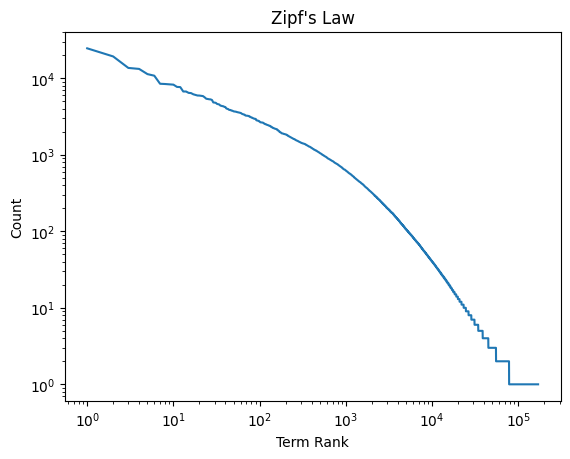

In [ ]:
plt.figure()

rank = 1 + np.arange(len(frequencies))

# plot usando una scala logaritmica
plt.loglog(rank, frequencies)

plt.xlabel('Term Rank')
plt.ylabel('Count')
plt.title('Zipf\'s Law')
plt.show()

**About Zipf's Law**

The graph shows the typical behavior of Zipf's Law. The removal of stopwords has resulted, obviously, in the deletion of the "head" of the distribution, which consists of the high-frequency terms that occupy the top ranks ($r=1, 2, 3, \dots$).

Zipf's Law gives us an important results: that we can deal with the majority of stemming operations by saving only the head of the distribution. How many of them? Given a cache size $C$ we can compute an ideal _hit rate_ with the following formula

$$\text{hit rate}=\frac{\sum_{i=1}^C \frac{1}{i}}{\sum_{i=1}^{|V|}\frac{1}{i}}$$

where $K$ is not considered as it is eliminated by the division. Let's compute the cache size $C$ by expressing an ideal _hit rate_ of 80%.

In [ ]:
# Denominator
denominator = 0

# V_estimated = dimension of vocabulary estimated with the k and beta values of the heaps law
for i in range(1, V_estimated + 1):
    denominator += 1.0 / i

# Target numerator (80% of the denominator)
target_sum = 0.8 * denominator

# Find target C
sum_zipf = 0    # rappresenta il numeratore
C = 0           # rappresenta il numero di token necessari per arrivare a un hit rate dell'80%

# appena superiamo l'hit rate dell'80% ci fermiamo e salviamo il numero di token al quale siamo arrivati
for i in range(1, V_estimated + 1):
    sum_zipf += 1.0 / i

    if sum_zipf >= target_sum:
        C = i
        break

print(f"--- Results by supposing an ideal 80% hit rate ---")
print(f"Computed C value: {C}")
print(f"Cached percentage of the vocabulary: {(C/V_estimated)*100:.2f}%")

--- Results by supposing an ideal 80% hit rate ---
Computed C value: 121216
Cached percentage of the vocabulary: 4.64%


## 1.3. Instance of Preprocessor class

Now we're able to define an instance of the `Preprocessor` class. This instance will be used in all subsequent sections in order to allow LRU Cache's usage in Evaluation.

In [ ]:
# 121216 = dimensione della cache, ricavato dallo zipf law assumendo sufficiente un hit rate dell'80%
preprocessing = Preprocessor(121216)

Let's check the _hit rate_ by applying the preprocessing to the entire database:

In [ ]:
for doc in tqdm(ds.docs_iter(), total=stats_dataset['documents'], desc='Indexing'):
  preprocessing(doc.text)

# Cache information
info = preprocessing.stemming_function.cache_info()
print(f"Hits: {info.hits} | Misses: {info.misses} | Hit Rate: {info.hits / (info.hits + info.misses):.2%}")

Indexing:   0%|          | 0/8841823 [00:00<?, ?it/s]

Hits: 291193254 | Misses: 8969972 | Hit Rate: 97.01%


The results shows us a 97% hit rate, which is far superior than the expected 80% rate. The very high rate is a good news, but we wonder why we achieved this result.

We must remember that Heap's Law and Zipf's Law are not theorems, but empirical laws. The Heap's law returned us a prediction of the vocabulary size which is higher than the effective vocabulary size. Also, Zipf's Law is strictly linked to the ranking of _words_ and other aspects (such as user behaviour or documents characteristics) are not taken into consideration.

# **2. Inverted Index**

## 2.1. Base Inverted Index

### 2.1.1. Construction

In [ ]:
@profile
def build_index(ds, total_docs):

    # {token: [termid, document_frequency, collection_frequency]}
    lexicon = {}

    # (doc_id, doc_len)
    doc_index = []

    # {term_id: [docid1, docid2, ...]}
    inv_d = defaultdict(list)

    # {termid: [tf_docid1, tf_docid2, ...]}
    inv_f = defaultdict(list)

    termid = 0
    num_docs = 0
    total_dl = 0
    internal_docid = 0

    # tqdm => displays a dynamic progress bar
    # for each document:
    for doc in tqdm(ds.docs_iter(), total=total_docs, desc='Indexing'):
        tokens = preprocessing(doc.text)

        # term frequences in the single document
        token_tf = Counter(tokens)

        # for each token:
        for token, tf in token_tf.items():
            # if the token is not present in the lexicon, we register it with a new termid
            if token not in lexicon:
                lexicon[token] = [termid, 0, 0]
                termid += 1

            # updating of the data structures for that specific term
            token_id = lexicon[token][0]
            inv_d[token_id].append(internal_docid)
            inv_f[token_id].append(tf)

            # increment the document frequency: number of documents in which the term appears
            lexicon[token][1] += 1

            # update the collection frequency: total number of term occurrences in the whole collection
            lexicon[token][2] += tf

        doclen = len(tokens)

        # save in the document index the original ID (string) and the document length
        doc_index.append((doc.doc_id, doclen))

        total_dl += doclen
        num_docs += 1
        internal_docid += 1

    stats = {
        'num_docs': num_docs,
        'num_terms': len(lexicon),
        'num_tokens': total_dl,
    }

    # Convert lists to NumPy arrays for inv_d and inv_f before returning
    for term_id in inv_d:
        inv_d[term_id] = np.array(inv_d[term_id], dtype=np.uint32)
        inv_f[term_id] = np.array(inv_f[term_id], dtype=np.uint32)

    # returns lexicon, inverted index, document index and collection statistics
    return lexicon, {'docids': inv_d, 'freqs': inv_f}, doc_index, stats

Execution of `build_index` function: choose one of the following two blocks

In [ ]:
# COMPLETE EXECUTION OF build_index FUNCTION AND UPDATE OF PICKLE FILES
if persistent_storage.get_drive_mode() == True:
  lex, inv, doc, stats = build_index(ds, stats_dataset['documents'])

  persistent_storage.save_data_structures({
      "lex_t": lex,
      "inv_t": inv,
      "doc_t": doc,
      "stats_t": stats
  })

In [ ]:
# SKIPPED EXECUTION OF build_index FUNCTION AND LOADING OF PRE-PROCESSED PICKLE FILES
lex, inv, doc, stats = persistent_storage.load_data_structures(["lex_t", "inv_t", "doc_t", "stats_t"])

[DONE] Data structure lex_t loaded from /content/IR
load_data_structure (3.360s)
[DONE] Data structure inv_t loaded from /content/IR
load_data_structure (23.077s)
[DONE] Data structure doc_t loaded from /content/IR
load_data_structure (1.777s)
[DONE] Data structure stats_t loaded from /content/IR
load_data_structure (0.003s)


In [ ]:
lex_bytes = sum(sys.getsizeof(v) + sys.getsizeof(k) for k, v in lex.items())
print(f"Lexicon uses approximately {humanize.naturalsize(lex_bytes, binary=True)}")

doc_index_bytes = sum(sys.getsizeof(t) + sys.getsizeof(t[0]) + sys.getsizeof(t[1]) for t in doc)
print(f"Document index uses approximately {humanize.naturalsize(doc_index_bytes, binary=True)}")

inv_bytes = sum(arr.nbytes for arr in inv['docids'].values()) + sum(arr.nbytes for arr in inv['freqs'].values())
print(f"Inverted index uses approximately {humanize.naturalsize(inv_bytes, binary=True)}")

Lexicon uses approximately 458.5 MiB
Document index uses approximately 1.1 GiB
Inverted index uses approximately 1.7 GiB


### 2.1.2. Data Structure
We use `__slots__` to reduce memory consumption, since we create a large number of objects during query processing. By avoiding the per-instance `__dict__`, we significantly lower memory overhead.

In [ ]:
class InvertedIndex:
    class PostingListIterator:
        __slots__ = (
          "docids", "freqs", "df", "doc",
          "num_docs", "total_doclen", "pos", "idf", "avdl"
        )

        def __init__(self, docids, freqs, doc, num_docs, total_doclen, df):
            self.docids = docids
            self.freqs = freqs
            self.df = df
            self.doc = doc
            self.num_docs = num_docs
            self.total_doclen = total_doclen

            # pointer of the current position in the posting list
            self.pos = 0

            # precomputed values because are always the same for the posting list
            self.idf = math.log(num_docs / df)
            self.avdl = total_doclen / num_docs

        # returns the id of the document in the current position (id equal to infinity if the list is ended)
        def docid(self):
            if self.is_end_list():
                return math.inf
            return self.docids[self.pos]

        # returns the score of the doc in the current position (score equal to infinity if the list is ended)
        def score(self, type='bm25'):
            if self.is_end_list():
                return math.inf

            # all the scoring function needs it
            tf = int(self.freqs[self.pos])

            if type == 'bm25':
                dl = self.doc[self.docid()][1]
                return bm25_score(tf=tf, dl=dl, avdl=self.avdl, idf=self.idf)
            elif type == 'tf':
                return tf_score(tf)
            elif type == 'tfidf':
                return tfidf_score(tf, self.idf)
            else:
                raise ValueError('scoring function error')

        # moves the iterator to the next posting
        def next(self, target=None):
            if not target:
                if not self.is_end_list():
                    self.pos += 1

            # advance the iterator to the next posting with a docid greater than or equal to the target
            else:
                # if the current docid is greater or equal to target, it does nothing
                if target > self.docid():
                    try:
                        # Use numpy's searchsorted for efficient searching in sorted arrays
                        idx = np.searchsorted(self.docids[self.pos:], target)
                        self.pos += idx
                    except ValueError:
                        self.pos = len(self.docids)

        # checks if the iterator has reached the end of the posting list
        def is_end_list(self):
            return self.pos >= len(self.docids)

        def len(self):
            return len(self.docids)

    # Inverted Index constructor
    def __init__(self, lex, inv, doc, stats):
        self.lexicon = lex
        self.inv = inv
        self.doc = doc
        self.stats = stats

        # per ricavare le informazioni di un termine a partire dal suo ID
        self.termid_to_terminfo = {}
        for term, (termid, df, cf) in self.lexicon.items():
            self.termid_to_terminfo[termid] = (df, cf)

   # returns the total number of documents in the collection
    def num_docs(self):
        return self.stats['num_docs']

    def total_doclen(self):
        return self.stats['num_tokens']

    # get the posting list of a specific term
    def get_posting(self, termid):
        # inv['docids'][termid] and inv['freqs'][termid] are already numpy arrays
        return InvertedIndex.PostingListIterator(self.inv['docids'][termid],
                                                 self.inv['freqs'][termid],
                                                 self.doc,
                                                 self.num_docs(),
                                                 self.total_doclen(),
                                                 self.termid_to_terminfo[termid][0])

    # get the termids of a list of tokens
    def get_termids(self, tokens):
        return [self.lexicon[token][0] for token in tokens if token in self.lexicon]

    # get the posting lists of a list of terms
    def get_postings(self, termids):
        return [self.get_posting(termid) for termid in termids]

In [ ]:
inv_index = InvertedIndex(lex, inv, doc, stats)

## 2.2. Quasi-Succint Inverted Index

A different approach suggested by Sebastiano Vigna is to build an optimized Inverted Index that exploit _Elias-Fano Compression algorithm_ to compress Posting Lists.
As the compression algorithm is part of the family of _Quasi-Succint Data Structures_, also the Inverted Index carries the same name.

- A succint data structure is able to store $b+\mathcal{o}(b)$ of memory (where $b$ is the number of bit for the bitmap and $\mathcal{o}(b)$ for auxilary data structures) and so very close to the theoretical information lower bound.
- Elias Fano is a loss-less compression Quasi-Succint algorithm because the compressed list occupies $2n+n \lceil \log \frac{u}{n}\rceil$ (where $n$ is the number of elements in the compressed data structure), that is also very close to the lower bound. The only requirement is to use it on a non-decreasing positive integer sequence.

A brief Q&A:
- **Why is important to compress posting list?**

  Inverted index file is the most large data structure in the inverted index and the more is small, the more it can fit in the Cache ("Focus. Speed. Faster than fast, quicker than quick. I am Lightning. I am speed"), reducing access in RAM. Consider also that posting list are the core of inverted index and there can be millions of access in a large list for a single query.
  
- **Why Elias Fano?**

  Not only the compression algorithm is very strong but also we can exploit some bitmap operation to access elements in the list, without fully decompress it (this can avoid cache-miss trashing)

- **How to compress also term-frequencies?**

  Posting list are defined by docId sequence and term-frequency sequence. Freqs is a strictly positive sequence but cannot be compressed as is with Elias Fano. Using prefix sums we can convert it in a non-decreasing positive integer sequence and so use Elias Fano

- **Where we can se the strength of QS-Inverted index?**

  Using EF compression with Posting list access operations, like next_geq, that exploit bitvector operations from SDSL [ovvero operazioni che lavorano su bit, come Rank(i) o Select(j)] (very fast), access time to an element of the list is granted to be $O(1)$

### 2.2.1. Elias-Fano compression

Hypothesis: Given a list  $0\leq x_0 \leq x_1 \leq …\leq x_{n-1}\leq u$
- $n$: number of elements in the list → $n>0$
- $x_{n-1}$: maximal value in the list
- $u$: upper bound/universe of the list → can be $u=x_{n-1}$ but for QS-Inverted index u : number of documents in the collection (normally it should be evaluated experimentally)

Compression
1. check if elements are ordered in increasing-order
2. consider the binary representation of each element with $\lfloor \log_2 u\rfloor$
2. divide each representation in two sides, upper bits and lower bits:
    1. $l=\lfloor \log_2 \frac{u}{n}\rfloor$bits for $LSB_i$ block
    2. the rest of bits for $MSB_i$ block
3. concat $LSB_i$ clocks in LSB_seq
4. calculate gaps $G_i=MSB_i - MSB_{i-1}$, considering $MSB_{-1}=0$
5. codify each gaps $G_i$ in unary code and concat all in MSB_seq

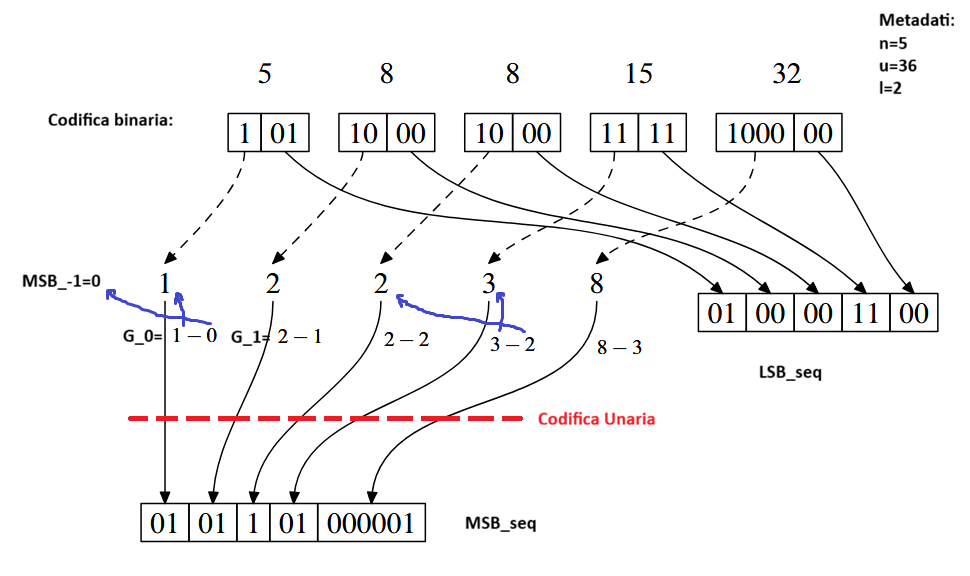


### 2.2.2. Hybrid Python-C++ approach: reasons
We have chosen an hybrid approach Python-C++ for the implementation of QS-Inverted Index.

- **Python's dynamic precision**

    Elias-Fano compression needs to use bitmap operations, but Python use dynamic precision to optimize memory: this leads to some bugs during simple programming. There are some solutions like _string representation_, _struct library_, _bitarray library_, but they introduce significant latency in the operation that compromise the efficiency of accessing the compressed lists. Also, We would need to implement SDSL operations in Python.

-  **Google Colab resources**

    On the other hands we can't implement QS-Inverted index fully in C++, that can import SDSL and allows fixed precision and strong typing, because we want to exploit Google Colabs resources. We also prefer take advantage of all the code just written in Python, transferring only the necessary parts (lexicon is easily handleable in Python).

This hybrid approach is possible thanks to _pybind11_.
- pybind11, according to its documentation, _is a lightweight header-only library that exposes C++ types in Python and vice versa, mainly to create Python bindings of existing C++ code_. It's an abstraction based on _Python/C API_.
- The C++ code is compiled into a `.so` file (Linux _Shared Object_), where _entry points_ are present thanks to the usage of `PYBIND11_MODULE` macro in C++ code. The Python interpreter is able to deal with `.so` files and Python bindings are managed as full-fledged Python modules. We can import them using `import module_name`.
- One of the main challenges in this hybrid approach is dealing with types: a C++ integer is obviously different from a Python integer, thus a conversion is necessary. C++ types are also decided on _compile-time_, while Python types are decided runtime and all data structures are treated as objects. The _pybind11_ library stores the conversion logic in the `.so` files, while effective type conversion is done _runtime_. This introduces an overhead which may be significant, based on input and output of C++-implemented functions.

Preliminary versions of our code consists of a C++-implementation limited only to the `InvertedIndex` class in C++ (compression of posting lists), with all other classes implemented in Python. We've verified that this implementation results in worsened performances: this is due to the significant number of type conversions. The expanded C++ implementation (which includes all data structures in the introduction of _2.2.3. C++ code block_) reduces context switches and, above all, allows us to significantly minimize type conversions.

### 2.2.3. C++ code block

The following data structures have been defined in the subsequent code block:
- **enum class ScoreType**
  
  Represents the different type of scoring function decided by python logic over queries performed : TF, TFIDF, BM25.

- **struct QueuePair**

  Representation of the pair $\langle \text{score}, \text{docid}\rangle$. Comparison between pairs is possible thanks to the overloading of the inequality operators `<` and `>` ($\text{score}$ values are compared, and $\text{docid}$ is used only as a tie-breaker).

- **class TopQueue**

  The priority queue used by DAAT and WAND to accumelate results.

- **class PostingList**

  Represents a Posting List, compressing the docIds and term-frequencies with Elias Fano compression. Contains also some metadata, additional structures and function to access elements in the list. Some function to serialize and deserialize the object are implemented to allow the correct saving in the binary file of the inverted index. There is also a function used to recalculate forward and skip pointers for the postinglist after loading the inverted index.

- **class PostingListIterator**

  As in python allows to access and go through posting lists. It contains a pointer to the posting list object and to doc_lens (document index) for bm25 score calculation.

- **struct TermState**

  An edited version of the _PostingListIterator_ that is used in WAND. Two additions: the `max_score` variable, the `TermState.docid()` method (it returns the relative _docid_).

- **class InvertedIndexQS**

  Handle all the inverted index logic and store inverted index file as vector of pointers to posting lists, document index, stats (lexicon is defined in python and handled by some wrappers that send only termId to C++ logic) and maxScores for WAND (calculated in python). This class allows to permorm DAAT and WAND query and save/load the inverted index on a binary file.

- **PYBIND11_MODULE**

  A Macro provided by the _pybind11_ library that allows creation of Python bindings. It allows C++ code to be exposed as a Python module by expliciting entry points in the `.so` file, making it accessible through a simple import command.

  `import elias_fano_module`

All the logic is putted inside a single code block to not get lost with different compilation blocks (for each C++ block you need a block with a terminal compilation command).

In [ ]:
%%writefile elias_fano.cpp
#include <pybind11/pybind11.h>
#include <pybind11/stl.h>
#include <vector>
#include <cmath>
#include <fstream>
#include <iostream>
#include <algorithm>
#include <sdsl/bit_vectors.hpp>
#include <sdsl/int_vector.hpp>
#include <queue>
#include <string>

namespace py = pybind11;
using namespace sdsl;
using namespace std;

//si potrebbero togliere gli std e alcuni controlli superflui con l'operatore ternario (inseriti per sicurezza)

//typedef uint64_t uintXX //si potrebbe usare per testare il codice a 64bit(uint64_t) o 32 bit (uint32_t)
//- Siccome ci sono n=8841823 documenti sono necessari almeno log2(n)=24 bit per docId e si dovrebbe usare uint32_t
//- Le cpu moderne elaborano meglio a blocchi di 64 bit alla volta e quindi si potrebbe sceglie di usare uint64_t

#define INF64 0xFFFFFFFFFFFFFFFF  //Ottimizzazione: Permette di inserire sengali nel ritorno di funzione di tipo uint64_t (errori, valore non trovato, ...)

enum class ScoreType {TF, TFIDF, BM25};

// tupla per poterla inserire nel TopQueue
struct QueuePair {
    double score;
    uint64_t docid;

    // Operator overloading: per confrontare tra loro due QueuePair andando a mettere a confronto gli score
    bool operator>(const QueuePair& other) const {
        if (score != other.score) {
            return score > other.score; // scores are compared
        }
        return docid > other.docid; // Tie-breaker
    }

    bool operator<(const QueuePair& other) const {
        if (score != other.score) {
            return score < other.score; // scores are compared
        }
        return docid < other.docid; // Tie-breaker
    }

    // Representation of a pair as a string. e.g: (4.23131, 1234) instead of an objectId (DAAT output in Python)
    std::string to_string() const {
        return "(" + std::to_string(score) + ", " + std::to_string(docid) + ")";
    }
};

class TopQueue {
    private:
        priority_queue<QueuePair, vector<QueuePair>, greater<QueuePair>> queue; //MinHeap
        size_t k; //Ottimizzazione: size_t garantisce di adattarsi automaticamente alla dimensione massima teorica gestibile dal sistema
    public:
        TopQueue(size_t k) : k(k) {}

        void insert(uint64_t docid, double score){
            if(queue.size() < k){
                queue.push({score, docid});
            } else if(score > queue.top().score){
                queue.pop();
                queue.push({score, docid});
            }
        }

        vector<QueuePair> get_sorted_results(){
            vector<QueuePair> result;
            while(!queue.empty()){
                result.push_back(queue.top());
                queue.pop();
            }
            reverse(result.begin(), result.end());
            return result;
        }

        double get_min() { return queue.top().score; }

        size_t size() { return queue.size(); } // Size of the queue
};

class PostingList {
    private:
        uint64_t n=0;    //numero elementi nella posting list e in cui il termine compare (df: document frequency)

        //====DOCID====//
        uint64_t l=0;     //numero di bit assegnati agli lsb
        //lsb e msb delle posting list
        int_vector<> lower_bits; //Ottimizzazione: int_vector vettore di interi con lunghezza personalizzata (invece di 32 anche un qualsiasi valore k>0)
        bit_vector upper_bits; //Ottimizzazione: bit_vector vettore di booleani (bitmap) che permette operazioni ottimizzate
        //Perchè usare strutture diverse ? Perchè la parte che occupa più spazio, necessita compressione e
        //permette di saltare il controllo di cluster di docIds (invece di usare una LENTA scansione lineare)
        //sono gli MSB mentre gli LSB possiamo usare l'accesso diretto quando abbiamo trovato un MSB accettabile (e scansionare linearmente quelli)
        //VEDI next_geq

        //Degli specie di "indici" di supporto per gli upper_bits(registrano le posizioni di 0 e 1 ogni alla bitmap/bitvecor a cui puntano)
        select_support_mcl<1> select_1; //Restituisce la posizione dell' i-esimo bit 1
        select_support_mcl<0> select_0; //Restituisce la posizione dell' i-esimo bit 0
        rank_support_v<1> rank_1; //Restituisce il numero di 1 nelle prine n posizioni

        //====FREQS====//
        uint64_t l_freq;  //numero di bit assegnati agli lsb
        //lsb e msb
        int_vector<> lower_bits_freq;
        bit_vector upper_bits_freq;
        select_support_mcl<1> select_1_freq;

        //Metadati postinglist
        double idf=0;
        double avdl=0;
    public:
        PostingList(){}

        //Comprime una postinglist(docIds e freqs) secondo Elias Fano e inizializza gli indici di supporto
        void compress(const std::vector<uint64_t>& docIds, const std::vector<uint64_t>& freqs, uint64_t u, double idf, double avdl){
            //Ottimizzazione: passare per riferimento i vettori evita i costruttori di copia(il male assoluto)

            //Metadati postinglist
            this->idf=idf;
            this->avdl=avdl;

            //====DOCIDS====//
            //Inizializzazione upper_bits e lower_bits
            n=docIds.size();
            if(n==0){l=0; return;}  //RIMUOVIBILE (non dovrebbero arrivare postinglist vuote)

            // u = massimo docid possibile
            l=(uint64_t)floor(std::log2((double)u/n));
            lower_bits=int_vector<>(n, 0, l>0?l:1);   //inizializza un vettore di n celle di lunghezza l a valore 0 di interi
            uint64_t upper_size=n+(u>>l);
            upper_bits=bit_vector(upper_size, 0);     // vettore di bit di dimensione upper size inizializzato a 0

            //Calcolo upper_bits e lower_bits
            for(size_t i=0; i<n; ++i){            //Ottimizzazione: ++i meglio di i++ perchè evita la creazione temporanea del valore originale
                uint64_t val = docIds[i];
                if (l > 0)
                    lower_bits[i] = val & ((1ULL << l) - 1);   //estrazione lsb (prendo solo gli ultimi l bit)

                uint64_t high = val >> l;   //estrazione msb
                if (high + i < upper_bits.size())
                    upper_bits[high + i] = 1;  // mette un "segnalibro" (un bit 1) alla posizione calcolata. In questo modo ho tanti zeri tra un 1 e l'altro quanto è il gap tra due MSB adiacenti
            }

            //====FREQS====//
            //Conversione in somme prefisse: in questo modo diventa sequenza crescente positiva (quindi comprimibile in Elias Fano)
            std::vector<uint64_t> prefix_sums;
            prefix_sums.reserve(freqs.size());
            uint64_t p_sum = 0;

            // creo la somma prefissa in modo da poter lavorare con elias fano anche per le frequenze
            for(size_t i=0; i<n; ++i){
                p_sum += freqs[i]; //SOMMA PREFISSA: sum_i=sum_i-i + freq_i -> ogni elemento è la somma delle frequenze precedenti
                prefix_sums.push_back(p_sum);
            }

            //Inizializzazione upper_bits e lower_bits
            uint64_t u_freq = p_sum;//L'ultima somma è l'elemento più grande della lista ed è quindi anche l'upper bound
            l_freq = (uint64_t)floor(std::log2((double)u_freq/n));
            lower_bits_freq = int_vector<>(n, 0, l_freq > 0 ? l_freq : 1);
            uint64_t upper_freq_size = n + (u_freq >> l_freq);
            upper_bits_freq = bit_vector(upper_freq_size, 0);
            //Calcolo upper_bits e lower_bits
            for(size_t i=0; i<n; ++i){
                uint64_t val = prefix_sums[i];
                if (l_freq > 0) lower_bits_freq[i] = val & ((1ULL << l_freq) - 1);
                uint64_t high = val >> l_freq;
                if (high + i < upper_bits_freq.size())
                    upper_bits_freq[high + i] = 1;
            }
            //Calcolo indici di supporto
            init_support();
        }

        // calcola gli indici di support, ovvero select_1, select_0 e rank_1. Ci serviranno per poter utilizzare SELECT e NEXTGEQ
        void init_support(){
        //Si usa funzione esterna per poter ricostruire gli indici in caso di ricaricamento dell'indice in memoria
        //(essendo un meccanismo a indirizzi non ha senso salvarli se tanto verrà ricaricato tutto in aree di
        //indirizzamento diverse. Si fa prima a ricostruirli al ricaricamento)
            if (n > 0) {
                //DOCIDS
                select_1 = select_support_mcl<1>(&upper_bits);
                select_0 = select_support_mcl<0>(&upper_bits);
                rank_1 = rank_support_v<1>(&upper_bits);
                //FREQS
                select_1_freq = select_support_mcl<1>(&upper_bits_freq);
            }
        }

        // ********** SELECT ************ //
        //Restituisce docId alla posizione i della posting list
        uint64_t select(uint64_t i) const {
            // n = numero di documenti nella posting list
            if(i>=n) return INF64; //Segnalazione errore di accesso ('0' esiste come docID, si potrebbero usare i valori negativi ma si sprecherebbero bit di rappresentazione)

            // 1. Recupero degli LSB (Lower Bits) --> O(1)
            uint64_t low = (l > 0) ? lower_bits[i] : 0;

            // 2. Recupero degli MSB (Upper Bits)
            uint64_t pos = select_1(i + 1); //la select trova i-esimo bit 1 (che è lo stopbit del gap)
            uint64_t high = pos - i;//Essendo gap_i=msb_i-1 e msb_i in unario selezionando il gap i+1, si ricava msb_i

            return (high << l) | low;   // l = dimensione del blocco LSBi
        }

        // ******** SELECT_FREQ ******** //
        // Serve per lavorare sulla lista delle frequenze, che abbiamo trasformato in somme prefisse in modo da avere una lista monotona non decrescente
        //Restituisce somma prefissa alla posizione i della posting list
        uint64_t select_freq(uint64_t i) const {
            if (i >= n) return 0; //Non può esistere frequenza 0 nelle somme prefisse (ottimo sengalatore di errore)

            // 1. Recupero degli LSB (Lower Bits) --> O(1)
            uint64_t low = (l_freq > 0) ? lower_bits_freq[i] : 0;

            // 2. Recupero degli MSB (Upper Bits)
            uint64_t pos = select_1_freq(i + 1);
            uint64_t high = pos - i;

            return (high << l_freq) | low;
        }

        // *********** NEXTGEQ ******** //
        //Restituisce il docId>=b a partire da start_idx (per via dell'iteratore)
        uint64_t next_geq(uint64_t b, uint64_t start_idx) const {
            if (start_idx >= n) return n;

            //Se già lo start_idx è >=b allora abbiamo già il valore target(deh pefforza, si va a letto!)
            uint64_t current_val = select(start_idx);
            if (current_val >= b) return start_idx;

            // 1. Calcolo dell'MSB target (ora abbiamo l'MSBi del valore "b")
            uint64_t b_msb = b >> l; //Calcolo msb di b -> es: [0010] in unario è [001]
            uint64_t num_zeros = upper_bits.size() - n; //numero massimo di zeri disponibili in msb_seq (basta togliere gli n stopbit)

            //msb originali:                 [0001] [0101] [0111] [1111]  -> (0 implicito),1,5,7,15
            //gaps=msb_i - msb_i-1:          [0001] [0100] [0010] [1000]  -> 1-0, 5-1, 7-5, 15-7
            //unario(1):                     [01]   [0001] [001] [000000001]  ->1 zero, 4 zeri, 2 zeri, 8 zeri
            //il numero di zeri indica quinta distanza c'è tra un msb e il precedente, quindi più zeri contiamo in unario più ci allontaniamo dalla "distanza 0", ovvero msb_-1

            // 2. Lo SKIP intelligente (O(1))
            //Fase di skip O(1) sugli upper_bits (si cerca di arrivare il più vicino possibile a b)
            uint64_t idx = start_idx;
            if (b_msb > 0) {//Se b_msb=[0000] allora sicuramente ci troviamo nel primo blocco e non si applica skipping
                if (b_msb > num_zeros) return n; //Se cerchiamo un blocco oltre il massimo rappresentabile allora restituiamo errore

                // Cerchiamo dove iniziano i valori che hanno almeno l'MSB che cerchiamo
                uint64_t pos_zero = select_0(b_msb);      //a questo punto abbiamo trovato il bit dove fermarci con lo skip

                // Contiamo quanti '1' (ovvero quanti elementi) ci sono prima di quella posizione
                uint64_t skip_idx = rank_1(pos_zero);   //[0001|0001|001|001|POSIZIONEATTUALE|00b001]
                if (skip_idx > idx) idx = skip_idx;     //controlliamo se skip_idx>start_idx perchè potremmo avere skip_idx>start_idx>b se start_idx è su uno "0"
            }

            // Poiché più numeri possono avere lo stesso MSB ma LSB diversi, serve il piccolo ciclo while finale per trovare il punto esatto.
            while (idx < n) {
                if (select(idx) >= b) return idx;
                idx++;
            }
            return n;
        }

        //Serializzazione dati posting list
        // in modo da salvare l'inverted index in un file binario, per non doverlo ricostruire ogni volta
        void write_to_stream(std::ofstream& out){
            out.write((char*)&n, sizeof(n));
            out.write((char*)&l, sizeof(l));
            out.write((char*)&l_freq, sizeof(l_freq));
            out.write((char*)&idf, sizeof(idf));
            out.write((char*)&avdl, sizeof(avdl));
            if (n > 0) {
                sdsl::serialize(lower_bits, out);
                sdsl::serialize(upper_bits, out);
                sdsl::serialize(lower_bits_freq, out);
                sdsl::serialize(upper_bits_freq, out);
            }
        }
        //Deserializzazione dati posting list, per poter caricare l'inverted index dal file binario
        void read_from_stream(std::ifstream& in){
            in.read((char*)&n, sizeof(n));
            in.read((char*)&l, sizeof(l));
            in.read((char*)&l_freq, sizeof(l_freq));
            in.read((char*)&idf, sizeof(idf));
            in.read((char*)&avdl, sizeof(avdl));
            if (n > 0) {
                sdsl::load(lower_bits, in);
                sdsl::load(upper_bits, in);
                sdsl::load(lower_bits_freq, in);
                sdsl::load(upper_bits_freq, in);
                init_support(); //Ricostruisce gli indici(nella serializzazione come detto non vengono salvati)
            }
        }

        //Metodi di accesso ai metadati della posting list per l'iteratore
        uint64_t size() const {return n;}
        double get_idf() const {return idf;}
        double get_avdl() const {return avdl;}
};

class PostingListIterator {
private:
    const PostingList* pl;        //puntatore ai dati della posting list
    uint64_t current_idx;
    const int_vector<>* docs_len; //Ottimizzazione: invece di avere una copia di questo vettore IDENTICO PER OGNI postinglist si lascia un puntatore al dato nel inverted index

public:
    PostingListIterator(const PostingList* pl, const int_vector<>* docs_len)
        : pl(pl), current_idx(0), docs_len(docs_len) {}

    //Restituisce docId corrente
    uint64_t docid() const {
        return pl->select(current_idx);       // si sfrutta la funzione SELECT(idx)
    }

    //Restituisce lo score del docId corrente
    double score(ScoreType type=ScoreType::BM25) {
        if(is_end()) return 0.0;

        //Recupero term frequency del docId corrente
        uint64_t curr_sum = pl->select_freq(current_idx); //RICORDA: la posting list salva somme prefisse
        uint64_t prev_sum = (current_idx == 0) ? 0 : pl->select_freq(current_idx - 1);
        double tf = (double)(curr_sum - prev_sum); //SOMMA PREFISSA: sum_i=sum_i-i + freq_i

        if(type == ScoreType::TF) {
            return tf > 0.0 ? 1.0 + std::log(tf) : 0.0;
        } else if(type == ScoreType::TFIDF) {
            return tf > 0.0 ? (1.0 + std::log(tf)) * pl->get_idf() : 0.0;
        } else { //BM25
            double k1 = 1.2;
            double b = 0.75;
            double dl = (double)(*docs_len)[docid()];
            double avdl = pl->get_avdl();
            double num = tf;
            double den = tf + k1 * (1 - b + b * (dl / avdl));
            return (num / den) * pl->get_idf();
        }
    }

    //Incrementa l'iteratore se possibile
    void next() {
        if(!is_end()) current_idx++;
    }

    //Salta al primo docId>=b
    void advance(uint64_t b) {
        current_idx = pl->next_geq(b, current_idx);       // sfrutta la NEXT_GEQ(b, curr_idx)
    }

    //Controllo se l'iteratore ha terminato
    bool is_end() const {
        return current_idx >= pl->size();
    }
    //Restituisce dimensioni postinglist
    uint64_t size() const { return pl->size(); }
};

struct TermState{ // Used in WAND (Edited iterator, maxscore is also included)
    PostingListIterator it;
    double max_score;

    uint64_t docid() const {return it.docid(); } // It returns iterator's docId
};

class InvertedIndexQS {
    friend class PostingListIterator;
private:
    std::vector<PostingList> pool;        //Inverted index file (tutte le posting list)
    int_vector<> docs_len;                //Document index (nel nostro caso contiene solo le doc_len) -> i docId sono esattamente gli indici del vettore
    //stats index (i metadati globali)
    uint64_t u=0;                         //massimo docId rappresentabile (il numero totale di documenti), nonchè universe della compressione
    uint64_t num_terms=0;
    uint64_t num_tokens=0;
    //Perchè non c'è il lexicon? Tanto si usa solo in ingresso alla Daat, a sto punto lo lasciamo in C++
    std::vector<std::vector<double>> maxScores;   //non allocato durante l'inizializzazione ma calcolato e fornito da python per WAND
public:
    InvertedIndexQS(){}
    uint64_t num_docs() { return u; }

    //Restituisce l'iteratore della postinglist delt termId specificato
    PostingListIterator get_posting(uint64_t id) {
        if (id >= pool.size()) throw std::out_of_range("Term Id out of range");
        return PostingListIterator(&pool[id], &docs_len);
    }

    //Aggiunge una postinglist al inverted index file (chiamato dalla build_index di python iterativamente per non causare crush della RAM)
    void add_postinglist(const std::vector<uint64_t>& docIds, const std::vector<uint64_t>& freqs, double idf, double avdl) {
        PostingList ef;
        ef.compress(docIds, freqs, u, idf, avdl);
        pool.push_back(std::move(ef)); //Ottimizzazione: la move è un istruzione di "casting" che trasforma lvalue in rvalue, permettendo contemporaneamente di svuotare il contenuto di ef e ricopiarlo dentro pool invece di costruirne una copia e avere in un certo istante due copie dello stesso oggetto (evita quindi il MALE ASSOLUTO, ovvero il costruttore di copia)
    }

    //Chiamata dalla build_index di python, costruisce in c++ stats e document index
    void build_index(const std::vector<uint64_t>& stats, const std::vector<uint64_t>& doc_index) {
        //STATS
        u = stats[0];         // u è uguale al numero di documenti
        num_terms = stats[1];
        num_tokens = stats[2];
        size_t n = doc_index.size();
        //DOCS
        docs_len = int_vector<>(n, 0, 32);
        for (size_t i = 0; i < n; ++i) docs_len[i] = doc_index[i];
        //INV_FILE
        pool.reserve(num_terms); //prealloca inverted index file (ATTENZIONE: fail della RAM a causa di numerose resizing dell'array dovute dal ciclo di add_posting)
    }
    //Chiamata da python
    void build_maxScores(std::vector<std::vector<double>>& scores){
        maxScores=scores;
    }

    //query_process_daat in python fornisce gli id dei token nella query, interrogando il lexicon(che si trova in python) e vi restituisce i topk score dei documeni
    std::vector<QueuePair> query_process_daat(std::vector<uint64_t> qtermids, ScoreType scoring_function, uint8_t k=10) {//DAAT in OR
        if (qtermids.empty()) return {};

        //Filtraggio postinglist relative ai tokens della query
        std::vector<PostingListIterator> iterators;
        for (uint64_t termid : qtermids) {
            if (termid < pool.size()) {
                iterators.push_back(get_posting(termid));
            }
        }
        if (iterators.empty()) return {};

        //Inizializzazione priority queue
        TopQueue top(k);

        while (true) {
            uint64_t min_docid = INF64; //questo docId è il più grande possibile e non esiste

            //Trova il minimo docId tra tutti gli iteratori non terminati
            bool all_ended = true;
            for (PostingListIterator& it : iterators) { //passato per riferimento per non far costruire una copia e permettere l'avanzamento dell'iteratore
                if (!it.is_end()) {
                    if (it.docid() < min_docid) {
                        min_docid = it.docid();
                    }
                    all_ended = false;
                }
            }

            if (all_ended) break; //Tutti gli iteratori sono finiti

            //Somma gli score del min_docid da tutte le postinglist che lo contengono
            double current_score = 0.0;
            for (PostingListIterator& it : iterators) {
                if (!it.is_end() && it.docid() == min_docid) {
                    current_score += it.score(scoring_function);
                    it.next(); //Avanza solo gli iteratori che hanno contribuito
                }
            }

            //Inserimento dentro la queue
            top.insert(min_docid, current_score);
        }

        return top.get_sorted_results(); //riordina i risultati secondo score e li restituisce
    }



    std::tuple<std::vector<QueuePair>,uint64_t,uint64_t> query_process_wand(std::vector<uint64_t> qtermids, ScoreType scoring_function, size_t k=10) {
        if (qtermids.empty()) return std::make_tuple(std::vector<QueuePair>{}, 0, 0);

        //Filtraggio postinglist relative ai tokens della query
        uint64_t max_score_calls=0;
        uint64_t score_calls=0;
        std::vector<TermState> iterators;
        for (uint64_t termid : qtermids) {
            if (termid < pool.size()) {
                PostingListIterator pli=get_posting(termid);
                max_score_calls+=pli.size();
                double up = 0.0; // Initialize upper bound
                // Defensive check before accessing maxScores
                if (termid < maxScores.size()) {
                    // Usiamo reference per evitare copie inutili nel loop
                  const std::vector<double>& term_max_scores = maxScores[termid];
                  if (!term_max_scores.empty() && static_cast<size_t>(scoring_function) < term_max_scores.size()) {
                      up = term_max_scores[static_cast<int>(scoring_function)];
                  }
                }
                //
                iterators.push_back({pli,up});
            }
        }
        if (iterators.empty()) return std::make_tuple(std::vector<QueuePair>{}, 0, 0);;

        std::vector<TermState*> cur_iterators; //salvo i puntatori a iteretors così ordino dei puntatori invece degli oggetti stessi
        for (TermState& it : iterators) {
            if (!it.it.is_end()) {
                cur_iterators.push_back(&it);
            }
        }

        //Inizializzazione priority queue
        TopQueue top(k);
        double threshold=0.0; //la metto qui invece che dentro la queue

        while(cur_iterators.size()>0) {

            //Ordinamento per docId crescente
            std::sort(cur_iterators.begin(), cur_iterators.end(),
                [](const TermState* a, const TermState* b) {
                    return a->docid() < b->docid();
                }
            );
            double sum_max = 0.0;
            int pivot_idx = -1;
            uint64_t pivot_docid = INF64;
            for(size_t i = 0; i < cur_iterators.size(); ++i){
                sum_max += cur_iterators[i]->max_score;
                if (sum_max > threshold) {
                    pivot_idx = i;
                    pivot_docid = cur_iterators[i]->it.docid();
                    break;
                }
            }

            if (pivot_idx == -1) {
              break;
            }

            uint64_t first_docid = cur_iterators[0]->docid();

            if(first_docid==pivot_docid){
              double score=0;


              size_t term_idx=0;
              while(term_idx<cur_iterators.size() && cur_iterators[term_idx]->it.docid()==pivot_docid){
                score+=cur_iterators[term_idx]->it.score(scoring_function);
                cur_iterators[term_idx]->it.next();
                term_idx++;
                score_calls++;
              }

              if(score>threshold){
                top.insert(pivot_docid, score);
                if(top.size()==k){
                  threshold=top.get_min();
                }
              }

            }
            else{
              cur_iterators[0]->it.advance(pivot_docid);
            }
              std::vector<TermState*>::iterator new_end = std::remove_if(cur_iterators.begin(), cur_iterators.end(),
                [](TermState* tit){ return tit->it.is_end(); });
              cur_iterators.erase(new_end, cur_iterators.end());
        }
        return make_tuple(top.get_sorted_results(),score_calls,max_score_calls); //riordina i risultati secondo score e li restituisce
    }


    //Salvataggio in file binario delle strutture dati del inverted index
    void save_table(std::string filename) {
        std::ofstream out(filename, std::ios::binary);
        if (!out) throw std::runtime_error("Cannot write file");
        out.write((char*)&u, sizeof(u));
        out.write((char*)&num_terms, sizeof(num_terms));
        out.write((char*)&num_tokens, sizeof(num_tokens));
        sdsl::serialize(docs_len, out);
        size_t count = pool.size();
        out.write((char*)&count, sizeof(count));
        for (auto& ef : pool) ef.write_to_stream(out);
        out.close();
    }
    //Ricaricamento dal file binario delle strutture dati nel inverted index
    void load_table(std::string filename) {
        std::ifstream in(filename, std::ios::binary);
        if (!in) throw std::runtime_error("Cannot read file");
        pool.clear();
        in.read((char*)&u, sizeof(u));
        in.read((char*)&num_terms, sizeof(num_terms));
        in.read((char*)&num_tokens, sizeof(num_tokens));
        sdsl::load(docs_len, in);
        size_t count;
        in.read((char*)&count, sizeof(count));
        pool.resize(count);
        for (size_t i = 0; i < count; ++i) pool[i].read_from_stream(in);
        in.close();
    }
};

//Parsing delle funzioni richiamabili da python
// Per ogni classe implementata su C++ è possibile richiamare su python le seguenti funzioni
PYBIND11_MODULE(elias_fano_module, m) {
    py::enum_<ScoreType>(m, "ScoreType")
        .value("BM25", ScoreType::BM25)
        .value("TF", ScoreType::TF)
        .value("TFIDF", ScoreType::TFIDF);

    py::class_<QueuePair>(m, "QueuePair")
        .def_readonly("docid", &QueuePair::docid)
        .def_readonly("score", &QueuePair::score)
        .def("__repr__", &QueuePair::to_string);

    py::class_<PostingListIterator>(m, "PostingListIterator")
        .def("docid", &PostingListIterator::docid)
        .def("next", &PostingListIterator::next)
        .def("advance", &PostingListIterator::advance)
        .def("score", &PostingListIterator::score)
        .def("is_end", &PostingListIterator::is_end);

    py::class_<InvertedIndexQS>(m, "InvertedIndexQS")
        .def(py::init<>())
        .def("num_docs", &InvertedIndexQS::num_docs)
        .def("add_postinglist", &InvertedIndexQS::add_postinglist)
        .def("get_posting", &InvertedIndexQS::get_posting)
        .def("build_index", &InvertedIndexQS::build_index)
        .def("build_maxScores", &InvertedIndexQS::build_maxScores)
        .def("query_process_daat", &InvertedIndexQS::query_process_daat)
        .def("query_process_wand", &InvertedIndexQS::query_process_wand)
        .def("save_table", &InvertedIndexQS::save_table)
        .def("load_table", &InvertedIndexQS::load_table);
}

Writing elias_fano.cpp


We have generated a cpp file thanks to magic command `%%writefile` in the first row of the previous block.

With the following compilation command it generated the library used by python to call C++ functions

In [ ]:
!g++ -O3 -Wall -shared -std=c++11 -fPIC $(python3 -m pybind11 --includes) -I/usr/local/include elias_fano.cpp -o elias_fano_module$(python3 -c "import sysconfig; print(sysconfig.get_config_var('EXT_SUFFIX'))") -L/usr/local/lib -lsdsl -ldivsufsort -ldivsufsort64
import elias_fano_module

### 2.2.4. Construction of the QS Inverted Index

In [ ]:
@profile
def build_index_compressed(ds, total_docs):
    lexicon = {}
    doc_index = []

    inv_d = defaultdict(list)
    inv_f = defaultdict(list)

    termid = 0
    total_dl = 0
    internal_docid = 0

    print("Build effettiva del inverted index")
    # Iterazione documenti
    for doc in tqdm(ds.docs_iter(), total=total_docs, desc='Indexing'):
        tokens = preprocessing(doc.text)
        token_tf = Counter(tokens)

        for token, tf in token_tf.items():
            if token not in lexicon:
                lexicon[token] = [termid, 0, 0]
                termid += 1

            token_id = lexicon[token][0]
            inv_d[token_id].append(internal_docid)
            inv_f[token_id].append(tf)

            lexicon[token][1] += 1
            lexicon[token][2] += tf

        doclen = len(tokens)

        doc_index.append(doclen)

        total_dl += doclen
        internal_docid += 1

    stats = [internal_docid, len(lexicon), total_dl]
    print(f"Stats calcolate: Docs={stats[0]}, Terms={stats[1]}, Tokens={stats[2]}")

    print("Inizializzazione Indice C++")

    # tramite elias_fano_module è possibile accedere alle classi e alle funzioni implementate in C++
    manager = elias_fano_module.InvertedIndexQS()
    manager.build_index(stats,doc_index)

    print("Compressione e inserimento Posting Lists...")
    for tid in tqdm(range(len(lexicon)), desc="Compressing"):
        if tid in inv_d:
            docs = inv_d[tid]
            freqs = inv_f[tid]
            df = len(inv_d[tid]);
            idf = math.log(total_docs / df)
            avdl = total_dl / total_docs;

            manager.add_postinglist(docs, freqs,idf,avdl)
    return lexicon,manager

In [ ]:
# COMPLETE EXECUTION OF build_index_compressed FUNCTION AND UPDATE OF PRE-PROCESSED FILES
if persistent_storage.get_drive_mode() == True:
  lex, manager = build_index_compressed(ds, stats_dataset['documents'])  # Same lexicon of the base Inverted Index
  persistent_storage.save_data_structures(lex, "lex_t")

  manager.save_table(os.path.join(persistent_storage.get_base_path(),"invertedIndexFile.bin"))

In [ ]:
# SKIPPED EXECUTION OF build_index_compressed FUNCTION AND LOADING OF PRE-PROCESSED FILES
lex = persistent_storage.load_data_structure("lex_t")

manager = elias_fano_module.InvertedIndexQS()
manager.load_table(os.path.join(persistent_storage.get_base_path(),"invertedIndexFile.bin"))

[DONE] Data structure lex_t loaded from /content/IR
load_data_structure (3.079s)


In [ ]:
print(f'The inverted index requires {humanize.naturalsize(os.path.getsize(os.path.join(persistent_storage.get_base_path(),"invertedIndexFile.bin")),binary=True)}')

The inverted index requires 662.5 MiB


# **3. Ranked Retrieval**
In Information Retrieval, two main retrieval paradigms are commonly distinguished:

*   *Boolean retrieval*, which retrieves all documents that satisfy a boolean expression composed of query terms and logical operators (e.g., AND, OR). This model performs exact matching and does not provide any ranking among the retrieved documents. It is generally suitable for expert users who have a clear understanding of both their information needs and the structure of the document collection.
*   *Ranked retrieval*, which assigns a relevance score to each document with respect to the query and returns the documents ordered by decreasing estimated relevance. Typically, only the top K documents are presented to the user. This paradigm better supports vague or underspecified queries and is therefore the dominant approach in modern web search engines.

We have adopted the _Ranked retrieval_ method in the project.

## 3.1. Scoring functions

To order the documents in the collection with respect to the query we use a scoring function defined as $$s : Q \times D \to \mathbb{R}$$That function assigns a real number (score) $s(q, d)$ to every query-document pair $(q, d) \in Q \times D$. This score measure how well the document and the query "match".
- For a given query, the documents are ordered according to the (decreasing) value of the ranking function, and the top documents selected accordingly.
- In our application, we adopt the _Bag of Words_ model. In this model, a document is represented as an unordered set of terms. Under this representation, several different scoring functions can be defined to estimate the relevance between a query and a document.

We'll use the following scoring functions:

In [ ]:
def tf_score(tf): # Term Frequency (TF)
    return 1 + math.log(tf) if tf > 0 else 0

def tfidf_score(tf, idf): # TF-IDF (Inverse Document Frequency)
    return (1 + math.log(tf)) * idf if tf > 0 else 0

def bm25_score(tf, dl, avdl, idf, b=0.75, k=1.2): # Okapi BM25 (Best Matching 25)
    return (tf / (k * ((1-b) + b * dl / avdl) + tf)) * idf

* **Term Frequency (TF)**

  `1 + math.log(tf) if tf > 0 else 0`

  The _Term Frequency_ (TF) is one of the simplest scoring functions used in Information Retrieval.

  > **Hans P. Luhn**: The weight of a term is proportional to its raw (absolute) frequency.

  The justification for measuring word significance through usage frequency is based on the observation that an author tends to repeat certain terms while developing or elaborating on specific aspects of a subject. As a result, the more frequently a term occurs within a document, the more indicative it is of the document’s content and topic.  

  However, raw term frequency alone is not sufficient, since document relevance does not increase proportionally with the number of occurrences of a term. To address this issue, a logarithmic scaling of term frequency is commonly applied, which reduces the impact of very frequent terms while preserving their relative importance.

  The resulting scoring function is defined as $\displaystyle {s(q, d) = \sum_{t \in q \cap d} \begin{cases} 1 + \log(\text{tf}_{t,d}) & \text{se } \text{tf}_{t,d} > 0 \\ 0 & \text{altrimenti} \end{cases}}$

* **TF-IDF (Inverse Document Frequency)**

  `return (1 + math.log(tf)) * idf if tf > 0 else 0`

  Rare terms are more informative than frequent terms. Consider a term in the query that is rare in the collection (e.g., *electronics*). A document containing this term is very likely to be relevant to the query “electronics”. This is the main limitation of using term frequency alone. Karen Spärck Jones introduced <i>Inverse Document Frequency</i> (IDF), defined as: $${\text{idf}_t = \log \frac{N}{\text{df}_t}}$$

  where $\text{df}_t$ is the document frequency of term $t$ and $N$ is the total number of documents in the collection.

  Now, we can combine the *Inverse Document Frequency* with TF to form the <i>TF-IDF</i> scoring function:
  $${\text{TF-IDF}_{t,d} = \text{tf}_{t,d} \cdot \text{idf}_t}$$
  where $\text{tf}_{t,d}$ is the term frequency of term $t$ in document $d$.

* **Okapi BM25 (Best Matching 25)**

  `return (tf / (k * ((1-b) + b * dl / avdl) + tf)) * idf`

  BM25 is a probabilistic retrieval scoring function that extends the TF-IDF idea by introducing a partial document length normalization and a saturation effect for term frequency. It is widely used in modern information retrieval systems, including web search engines.  

  The BM25 scoring function for a document $d$ and a query $Q$ is defined as:

  $${\text{score}(q, d) = \sum_{t \in q} \frac{tf}{k_1 \left((1-b) + b\frac{\text{dl}}{\text{avdl}}\right) + tf}\cdot \text{idf}}$$
  where:
  - $\text{avdl}$ is the average document length in the collection.  
  - $k_1$ (typically [1.2, 2]) is a free parameter that control saturation of the term frequency, if the $k_1$ is lower the saturation comes fast.
  - $b$ (typically 0.75) is a free parameter controlling length normalization, if $b = 0$ (BM15) the lenght normalization is not applied, if $b = 1$ (BM11) a full normalization is applied.

## 3.2. Query Processing
_Query processing_ is the set of operations used to retrieve relevant documents from a collection based on a user query. Two common approaches are _Term-at-a-Time_ (TAAT) and _Document-at-a-Time_ (DAAT):

- **TaaT (Term-At-A-Time)**.  
  Processes one query term at a time. For each term, it retrieves the posting list of documents containing the term and updates the partial scores of all relevant documents before moving to the next term. It is cache friendly because for each terms, document in the same posting list are next in memory, but requires lot of memory to contain partial scores for all documents using a hash map.

- **DaaT (Document-At-A-Time)**.  
  Processes one document at a time across all query terms. It merges posting lists in a coordinated way so that the score for each document is computed once after considering all query terms. It has smaller memory footprint than TaaT because we don't memorize hash table for partial scores but is lesser cache friendly than TaaT.

In this application, we use two different DaaT strategies: the first implements the **basic DaaT algorithm**, while the second incorporates the **WAND** optimization to reduce the time required for query processing.

### 3.2.1. TopQueue class
To handle the top-k results efficiently during query processing, we use a _TopQueue_ class. Rather than keeping all candidate documents and sorting them at the end, this class maintains a min-heap containing only the k documents with the highest scores encountered so far.

In [ ]:
class TopQueue:
    __slots__ = ("queue", "k", "threshold")

    def __init__(self, k=10):
        self.queue = []
        self.k = k
        self.threshold = float("-inf")

    def size(self):
        return len(self.queue)

    def would_enter(self, score):
        return score > self.threshold

    def clear(self, new_threshold=None):
        self.queue = []
        if new_threshold:
            self.threshold = new_threshold

    def __repr__(self):
        return f'<{self.size()} items, th={self.threshold} {self.queue}'

    def insert(self, docid, score):
        # First check
        if score <= self.threshold:
            return False

        q = self.queue
        if len(q) < self.k:
            heapq.heappush(q, (score, docid))
            if len(q) == self.k:
              # The minimum of the value is always in first position
              self.threshold = q[0][0]
            return True

        heapq.heapreplace(q, (score, docid))
        self.threshold = q[0][0]
        return True

### 3.2.2. DaaT standard implementation
This section presents the standard implementation of the DaaT approach. In this setting, scores are computed for all documents that appear in at least one of the posting lists associated with the query tokens. The algorithm iterates over documents in increasing document identifier order and aggregates contributions from each relevant posting list to produce a final score for every candidate document.

In [ ]:
def query_process_daat(query, index, scoring_function, k = 10):
    """
    Parameters
    ----------
    query : str
        The textual query to be processed.
    index : object
        The inverted index object providing access to term IDs and posting
        lists.
    scoring_function : str
        The scoring function to use. Must be one of:
        - 'tf' : term frequency
        - 'tfidf' : term frequency–inverse document frequency
        - 'bm25' : BM25
    k : int, optional, default=10
        The number of top documents to return.

    Returns
    -------
    list
        A list of the top-k documents as tuples (docid, score),
        sorted in descending order of score.
    """

    # Give us the document with lower doc_id among the current posting lists
    def min_docid(postings):
      min_docid = math.inf
      for p in postings:
          if not p.is_end_list():
              min_docid = min(p.docid(), min_docid)
      return min_docid

    # From query --> tokens --> term_ids --> posting_lists
    # The set remove duplicates token
    qtokens = set(preprocessing(query))
    qtermids = index.get_termids(qtokens)
    postings = index.get_postings(qtermids)

    # Check if the scoring function is valid or not
    scoring_functions = ["tf", "tfidf", "bm25"]
    if scoring_function not in scoring_functions:
      raise ValueError('Invalid score type')

    #############################################
    #### Starts the DaaT implementation code ####
    #############################################
    top = TopQueue(k)
    current_docid = min_docid(postings)
    while current_docid != math.inf:
        # Let's start to compute the score for current_docid
        score = 0
        next_docid = math.inf
        for posting in postings:
            if posting.docid() == current_docid:
                score += posting.score(scoring_function)
                posting.next()

            # We search the next docid to compute
            if not posting.is_end_list():
                next_docid = min(next_docid, posting.docid())

        # We try to insert into topqueue and we restart the loop with new docid
        top.insert(current_docid, score)
        current_docid = next_docid

    #############################################
    ##### Ends the DaaT implementation code #####
    #############################################

    # We return the topk document in decreasing score order
    return sorted(top.queue, reverse=True)

### 3.2.2. DaaT parser for QS-Inverted index

In [ ]:
def get_termids_QS(qtokens):
  return [lex[token][0] for token in qtokens if token in lex]

def query_process_daat_QS(query, scoring_function, k = 10):
    qtokens = set(preprocessing(query))
    qtermids = get_termids_QS(qtokens)
    return manager.query_process_daat(qtermids, scoring_function, k)

### 3.2.3. DaaT implementation with WAND optimization
This section introduces an alternative DaaT implementation based on the WAND optimization. Unlike the standard DaaT approach, which computes scores for all candidate documents, WAND leverages **dynamic pruning strategies** using upper bounds on term contributions to **skip documents** that cannot reach the threshold of the top k results. By dynamically maintaining a pivot document and a score threshold, the algorithm avoids unnecessary score computations, significantly improving efficiency while preserving the correctness of the top-k results.

1.  <u><b>Define the upper bound for each posting list</b></u>.

    As anticipated earlier, the WAND implementation requires the definition of an upper bound for each posting list, representing the maximum contribution that a term can provide to the final score of a document. The following function computes these upper bounds and stores them in a dictionary, where each key corresponds to a term identifier and the associated value is a list of three upper bounds, one for each supported scoring function. This calculation must be performed again every time the posting lists are modified.

In [ ]:
@profile
def compute_max_scores(inv_index):
    # The file does not exists, then we will create it
    # { termid: [max_tf, max_tfidf, max_bm25] }
    maxScores = {}

    # For each posting lists compute score for each document
    for term in inv_index.lexicon:
      termid = inv_index.lexicon[term][0]
      posting_list = inv_index.get_posting(termid)

      max_tf = 0
      max_tfidf = 0
      max_bm25 = 0

      # For each document we memorize always the max of the score
      # for each scoring function that we have
      while not posting_list.is_end_list():
        max_tf = max(max_tf, posting_list.score('tf'))
        max_tfidf = max(max_tfidf, posting_list.score('tfidf'))
        max_bm25 = max(max_bm25, posting_list.score('bm25'))
        posting_list.next()

      # We save for that termid the three maxscores
      maxScores[termid] = [max_tf, max_tfidf, max_bm25]

    return maxScores

Execution of `compute_max_score` function: choose one of the following two blocks

In [ ]:
# COMPLETE EXECUTION OF compute_max_score FUNCTION AND UPDATE OF PICKLE FILE
if persistent_storage.get_drive_mode() == True:
  maxScores = compute_max_scores(inv_index)
  persistent_storage.save_data_structure(maxScores, "maxScores")

In [ ]:
# SKIPPED EXECUTION OF compute_max_score FUNCTION AND LOADING OF PRE-PROCESSED PICKLE FILE
maxScores = persistent_storage.load_data_structure("maxScores")

[DONE] Data structure maxScores loaded from /content/IR
load_data_structure (2.920s)


The following function is a parsing function <b><u>that must be executed</u></b> to make _max scores_ available to the _Quasi-Succint Inverted Index_

In [ ]:
manager.build_maxScores(maxScores.values())

2. <b><u>DaaT implementation with WAND optimization</u></b>.
  
   The following function implements the WAND optimization introduced earlier in this chapter, with comments to clarify its operation.
   
   During query processing, posting lists are ordered by current docid, and the upper bounds are summed progressively. When the sum reaches or exceeds the current top-k threshold, the corresponding posting list becomes the pivot posting list, and its current docid is the pivot docid. Using this pivoting technique, all documents with docid smaller than the pivot can be skipped, as they cannot enter the top-k. Only the pivot docid and, if necessary, subsequent documents are fully evaluated.
   
   This approach significantly reduces the number of score computations while preserving the correctness of the top-k results, provided the upper bounds are accurate.

In [ ]:
def query_process_wand(query, index, scoring_function, k = 10):
  """
  Parameters
  ----------
  query : str
      The textual query to be processed.
  index : object
      The inverted index object providing access to term IDs and
      posting lists.
  scoring_function : str
      The scoring function to use. Must be one of:
      - 'tf' : term frequency
      - 'tfidf' : term frequency–inverse document frequency
      - 'bm25' : BM25
  k : int, optional, default=10
      The number of top documents to return.

  Returns
  -------
  list
      A list containing three elements:
      - sorted top-k results as a list of tuples (docid, score), sorted in
        descending order of score
      - score_calls : int, the total number of score evaluations performed
      - max_score_calls : int, the total number of potential score
        evaluations (sum of lengths of all posting lists)
  """

  # From query --> tokens --> term_ids --> posting_lists
  # The set remove duplicates token
  qtokens = set(preprocessing(query))
  qtermids = index.get_termids(qtokens)
  postings = index.get_postings(qtermids)

  max_score_calls = 0
  # Count the total number of document in the posting lists in total
  # this is done only for statistical reasons and represent the maximum number
  # of times that a score method can be executed
  for posting in postings:
    max_score_calls += posting.len()

  # Retrieve max scores for each posting lists
  max_scores = []
  for termid in qtermids:
    if scoring_function == 'tf':
      max_scores.append(maxScores[termid][0])
    elif scoring_function == 'tfidf':
      max_scores.append(maxScores[termid][1])
    elif scoring_function == 'bm25':
      max_scores.append(maxScores[termid][2])
    else:
      raise ValueError('Invalid score type')

  #############################################
  #### Starts the WAND implementation code ####
  #############################################

  # per avere un oggetto che memorizza insieme la tupla (posting_list, maxscore)
  class TermState:
      # Is used __slots__ for faster attribute access and reduce the
      # space in memory
      # that each object instance takes up.
      __slots__ = ("posting", "maxscore", "docid")

      def __init__(self, posting, maxscore):
          self.posting = posting
          self.maxscore = maxscore

          # using this as cache
          self.docid = posting.docid()

  score_calls = 0
  # Build PostingList objects
  terms = []
  for posting, maxscore in zip(postings, max_scores):
      if not posting.is_end_list():
          terms.append(TermState(posting, maxscore))

  # Helper: sort all terms by current docid ascending
  def sort_terms():
    terms.sort(key=lambda ts: ts.docid)

  topk = TopQueue(k)
  # The biggest compromise is to keep the posting lists sorted among themselves
  # in ascending order of the current docid
  # the complexity of the sorting is O(n*log(n)), n = number of posting lists
  sort_terms()

  # fino a che tutte le posting list non sono vuote continuo il seguente ciclo
  while terms:

      # Now we compute pivot by accumulating max scores
      # The pivot posting lists will be the first posting lists therefore,
      # the sum of the upper bounds of the preceding posting lists up to
      # that point reaches or exceeds the current top-k threshold.
      sum_max = 0.0
      pivot_idx = None
      for i, ts in enumerate(terms):
        sum_max += ts.maxscore
        if sum_max > topk.threshold:
            pivot_idx = i
            break

      # Nothing else can beat threshold
      if pivot_idx is None:
          break

      # We gets the pivot_docid from the pivot posting list as its current
      # docid
      pivot_docid = terms[pivot_idx].docid
      first_docid = terms[0].docid

      # If the pivot docid coincides with the current minimum docid across
      # all posting lists, we **can safely proceed to compute the score
      # for this document**. According to the WAND property, **no document
      # with a smaller docid can reach the current top-k threshold**,
      # so evaluating the pivot is safe.
      if first_docid == pivot_docid:

          score = 0
          for ts in terms:
              # if the current docid of this current posting lists is grather
              # than the pivot_docid i can exit from the loop because the
              # posting lists are ordered by current docid
              if ts.docid > pivot_docid:
                break

              # if is lower than the pivot_docid i have to skip some document
              # which i'm sure wouldn't be included in the topk
              # [QUESTO CASO NON PUO' MAI VERIFICARSI]
              if ts.docid < pivot_docid:
                  p = ts.posting
                  p.next(pivot_docid)
                  ts.docid = p.docid()

              # if the current docid is the pivot i compute the complete
              # score value for it because i'm not sure that it won't be
              # included in the topk
              if ts.docid == pivot_docid:
                  score += ts.posting.score(scoring_function)
                  # for statistical reason
                  score_calls += 1

          # try to insert in the topk queue
          topk.insert(pivot_docid, score)

          # advance all terms that were at pivot_docid
          new_terms = []
          for ts in terms:
              if ts.docid == pivot_docid:
                  ts.posting.next()
                  ts.docid = ts.posting.docid()

              if not ts.posting.is_end_list():
                  new_terms.append(ts)

          terms = new_terms
          # i have to sorting the term among themself because i have made
          # some changes to the posting lists (skipping documents)
          sort_terms()

      else:
          # skipping, advance some term to at least pivot_doc because all docid
          # lower than pivot_docid cannot reach the current top-k threshold
          for ts in terms[:pivot_idx]:
            if ts.docid < pivot_docid:
                ts.posting.next(pivot_docid)
                ts.docid = ts.posting.docid()

          # remove euxhasted posting lists
          terms = [ts for ts in terms if not ts.posting.is_end_list()]
          # i have to sorting the term among themself because i have made
          # some changes to the posting lists (skipping documents)
          sort_terms()

  #############################################
  ##### Ends the WAND implementation code #####
  #############################################

  # return sorted top-k by descending score
  return [sorted(topk.queue, reverse=True), score_calls, max_score_calls]

### 3.2.4 DaaT with WAND for QS-Inverted Index

In [ ]:
# CREDO CHE SIA UGUALE A USARE InvertedIndex.get_termids [??]
def get_termids_QS(qtokens):
  return [lex[token][0] for token in qtokens if token in lex]

# per eseguire il query process WAND con l'inverted index su c++
def query_process_wand_QS(query, scoring_function, k = 10):
    qtokens = set(preprocessing(query))
    qtermids = get_termids_QS(qtokens)
    return manager.query_process_wand(qtermids, scoring_function, k)

# **4. Evaluate the Efficiency**
In this section, the efficiency of the system developed in the previous chapters is analyzed. The evaluation is based on measuring the execution time of queries and comparing the performance of the two query processing algorithms introduced earlier. For each query, the top 10 documents are returned, simulating the response time an end-user would experience in a typical search engine scenario.

Before recording execution times, a warm-up phase is performed using a subset of queries. This phase allows the system to stabilize by populating memory caches and initializing internal data structures, ensuring that subsequent measurements reflect steady-state performance rather than one-off startup overheads.

Each query is executed more times for each scoring function–algorithm pair to obtain more reliable results and reduce measurement noise. For each scoring function, the two algorithms are compared using statistical metrics such as *average* and *median* execution times. Additionally, for the WAND implementation, the percentage of potential scoring operations actually performed is reported to provide insight into its efficiency.


## 4.1. DAAT vs QS-DAAT
First, we compare the two inverted indexes in terms of query processing time: the standard inverted index and the inverted index compressed using Elias–Fano encoding. To perform this evaluation, we execute all queries using both `query_process_daat` and `query_process_daat_QS`, and then measure and compare their execution times.



In [ ]:
topics = list(ds.queries_iter())

In [ ]:
# funzione che controlla che i risultati dati dal query processing di Python e quelli dati dal quello di C++ siano gli stessi
def check_correcteness(res_py, res_c, show=False,  approx=4):
    print("____________________________________________________________")
    if len(res_py)!= len(res_c):
        print(f"The query function do not return same results: The first has: {len(res_py)}, The second has: {len(res_c)}")
    else:
      res_py=[(round(r[0],approx),int(r[1])) for r in res_py]
      res_c=[(round(r.score,approx),int(r.docid)) for r in res_c]
      errati = []
      i=1
      for elem in res_py:
        if elem not in res_c:
          errati.append(i)
        i+=1
      if len(errati) == 0:
          print("Same results for each queries")
      else:
          print(f"error in the positions: {errati}")
    if show:
      print(res_py)
      print(res_c)

In [ ]:
if persistent_storage.get_drive_mode() == True:
  score_functions = ["tf"]
  k = 10

  # si esegue due volte il query processing per ogni query, in modo da ottenere risultati più affidabili
  retry = 2

  score_type_map = {
      "tf": elias_fano_module.ScoreType.TF
  }

  # Warmup phase (esecuzione di 15 queries casuali per riempire la cache)
  random.seed(42)
  sample = random.sample(topics, 15)
  for score_function in score_functions:
    for topic in sample:
      # Execution of DAAT implementation with inverted index del prof
      res1=query_process_daat(topic.text, inv_index, score_function, k)
      # Execution of DAAT implementation with inverted index di QS
      res2=query_process_daat_QS(topic.text, score_type_map[score_function], k)
      # check_correcteness(res1, res2, True)

  for score_function in score_functions:
    # Evaluate phase
    query_times_inverted_index = []
    query_times_inverted_index_QS = []
    for topic in topics:
      for i in range(retry):
        # Execution of DAAT implementation with inverted index del prof
        start_time = time.perf_counter()
        query_process_daat(topic.text, inv_index, score_function, k)
        query_times_inverted_index.append(time.perf_counter() - start_time)

        # Execution of DAAT implementation with inverted index di QS
        start_time = time.perf_counter()
        query_process_daat_QS(topic.text, score_type_map[score_function], k)
        query_times_inverted_index_QS.append(time.perf_counter() - start_time)

    # Computes statistics for DAAT implementation with inverted index default
    avg_time = statistics.mean(query_times_inverted_index)
    median_time = statistics.median(query_times_inverted_index)

    print(f"The DAAT_{score_function.upper()} with default inverted index is finished.")
    print(f"Average execution time: {avg_time:.3f} s")
    print(f"Median execution time: {median_time:.3f} s")
    print("-" * 50)
    print("")

    # Computes statistics for DAAT implementation with inverted index di QS
    avg_time = statistics.mean(query_times_inverted_index_QS)
    median_time = statistics.median(query_times_inverted_index_QS)

    print(f"The DAAT_{score_function.upper()} with QS's inverted index is finished.")
    print(f"Average execution time: {avg_time:.3f} s")
    print(f"Median execution time: {median_time:.3f} s")
    print("-" * 50)

The DAAT_TF with default inverted index is finished.
Average execution time: 3.694 s
Median execution time: 2.630 s
--------------------------------------------------

The DAAT_TF with QS's inverted index is finished.
Average execution time: 0.342 s
Median execution time: 0.209 s
--------------------------------------------------


With the standard inverted index, the DAAT_TF execution has an average time of 3.694 seconds and a median time of 2.630 seconds. In contrast, using the QS (Elias–Fano compressed) inverted index, the average execution time drops to 0.342 seconds and the median to 0.209 seconds. This corresponds to a very big improvement.

These results demonstrate that the QS inverted index drastically reduces query time.

## 4.2 QS-DAAT vs QS-WAND
At this stage, we compare two different query processing strategies: the standard DAAT approach and the DAAT approach enhanced with WAND optimization.
To carry out this evaluation, we execute the full set of queries using both `query_process_daat_QS` and `query_process_wand_QS`, and then measure and compare their execution times to assess the performance impact of the WAND optimization.

In [ ]:
if persistent_storage.get_drive_mode() == True:
  score_functions = ["tf", "tfidf", "bm25"]
  k = 10
  retry = 2

  score_type_map = {
      "tf": elias_fano_module.ScoreType.TF,
      "tfidf": elias_fano_module.ScoreType.TFIDF,
      "bm25": elias_fano_module.ScoreType.BM25
  }

  # Warmup phase
  random.seed(42)
  sample = random.sample(topics, 15)
  for score_function in score_functions:
    for topic in sample:
      # Execution of DAAT implementation
      res1=query_process_daat_QS(topic.text, score_type_map[score_function], k)

      # Execution of WAND implementation
      res2=query_process_wand_QS(topic.text, score_type_map[score_function], k)
      # check_correcteness(res1,res2[0],True)

  # Evaluate phase
  for score_function in score_functions:
    total_results = []
    query_times_daat = []
    query_times_wand = []
    scores_calls_ratio = []
    speedups = []
    print(f"###### We evaluate the functions with {score_function.upper()}. ###### \n")

    for topic in topics:
      times_daat = []
      times_wand = []
      for i in range(retry):
        # Execution of DAAT implementation
        start_time = time.perf_counter()
        query_process_daat_QS(topic.text, score_type_map[score_function], k)
        time_daat = time.perf_counter() - start_time
        query_times_daat.append(time_daat)

        # Execution of WAND implementation
        start_time = time.perf_counter()
        results=query_process_wand_QS(topic.text, score_type_map[score_function], k)
        time_wand = time.perf_counter() - start_time
        query_times_wand.append(time_wand)
        if i == 0:
          # Will be the same in this loop
          scores_calls_ratio.append(results[1] / results[2])

        # Save the times for this speficic query
        times_daat.append(time_daat)
        times_wand.append(time_wand)

      # Compute the speedups to see if WAND is more fast than DAAT
      # Is computed only one time for each query
      median_times_daat = statistics.median(times_daat)
      median_times_wand = statistics.median(times_wand)
      if median_times_wand > 0:
        speedups.append(median_times_daat / median_times_wand)

    # Computes statistics for DAAT
    avg_time = statistics.mean(query_times_daat)
    median_time = statistics.median(query_times_daat)

    print(f"The DAAT_{score_function.upper()} is finished.")
    print(f"Average execution time: {avg_time:.3f} s")
    print(f"Median execution time: {median_time:.3f} s")
    print("-" * 50)
    print("\n")

    # Computes statistics for WAND
    avg_time = statistics.mean(query_times_wand)
    median_time = statistics.median(query_times_wand)
    avg_ratio = statistics.mean(scores_calls_ratio) * 100

    print(f"The WAND_{score_function.upper()} is finished.")
    print(f"Average execution time: {avg_time:.3f} s")
    print(f"Median execution time: {median_time:.3f} s")
    print(f"Average score calls ratio: {avg_ratio:.2f}%")
    print("-" * 50)
    print("\n")

###### We evaluate the functions with TF. ###### 

The DAAT_TF is finished.
Average execution time: 0.344 s
Median execution time: 0.211 s
--------------------------------------------------


The WAND_TF is finished.
Average execution time: 0.259 s
Median execution time: 0.136 s
Average score calls ratio: 34.86%
--------------------------------------------------


###### We evaluate the functions with TFIDF. ###### 

The DAAT_TFIDF is finished.
Average execution time: 0.345 s
Median execution time: 0.203 s
--------------------------------------------------


The WAND_TFIDF is finished.
Average execution time: 0.179 s
Median execution time: 0.075 s
Average score calls ratio: 17.97%
--------------------------------------------------


###### We evaluate the functions with BM25. ###### 

The DAAT_BM25 is finished.
Average execution time: 0.389 s
Median execution time: 0.263 s
--------------------------------------------------


The WAND_BM25 is finished.
Average execution time: 0.116 s
Me

The results clearly show that WAND significantly reduces query execution time. Thanks to its ability to skip the scoring phase for a large number of non-promising documents, WAND avoids unnecessary computations and focuses only on documents that can potentially enter the top-k results. This leads to substantially lower execution times compared to the standard DAAT approach.

Another interesting observation concerns the different scoring functions. The performance gap between scoring methods decreases when using WAND. Experimentally, we observed that the number of skipped documents increases when moving from simpler scoring functions, such as TF, to more complex ones like BM25. As a result, WAND becomes even more effective with computationally expensive scoring functions.

This is particularly advantageous because more sophisticated scoring models, such as BM25, typically require higher computational cost per document. The pruning strategy introduced by WAND compensates for this additional cost by reducing the number of documents that actually need to be scored, thus balancing efficiency and effectiveness.

# **5. Evaluate the Effectiveness**
The objective of this section is to evaluate the **effectiveness** of the Information Retrieval (IR) system.

**Effectiveness** refers to the system's ability to retrieve and correctly rank relevant documents while simultaneously minimizing the retrieval of non-relevant ones. The ultimate goal is to fulfill the user’s specific information needs

Our analysis is based on **offline evaluation**, which is characterized by the following principles:

*User-Independent Testing*: The IR system is evaluated without direct interaction with end-users. Instead, we rely on assessors (experts or trained judges) who can objectively determine which documents are relevant to a given query.

*The Cranfield Paradigm*: We employ the Cranfield paradigm, a standard evaluation framework based on experimental collections. These collections consist of three fundamental components:
*   `Document collection`, a corpus of documents in the domain of interest
*   `Topics`, representing the user information needs
*   `Relevance Assessments (Ground Truth)`: Often referred to as qrels, these represent the "correct" answers, indicating which documents in the collection are relevant for each specific topic.

## 5.1. Experimental Collection
For the **ranking evaluation**, we utilize the following components:

* **Test Queries**: The DL2019 query set (sourced from `msmarco-test2019-queries.tsv`) and the DL2020 query set (sourced from `msmarco-test2020-queries.tsv`).
* **Relevance Assessments (Qrels)**: The official ground truth for 2019 and 2020, specifically the passage-level files `2019qrels-pass.txt` and `2020qrels-pass.txt`.

Both the **Queries** and the **Qrels** from the 2019 and 2020 sets will be merged. We have chosen to aggregate these datasets to ensure the most comprehensive and statistically robust evaluation possible.


In [ ]:
topics = list(ds.queries_iter())
qrels = list(ds.qrels_iter())

Let us analyze the relevance assessments:

In [ ]:
qrels_df = pd.DataFrame(qrels)
qrels_df.head(10)

,query_id,doc_id,relevance,iteration
0,19335,1017759,0,Q0
1,19335,1082489,0,Q0
2,19335,109063,0,Q0
3,19335,1160863,0,Q0
4,19335,1160871,0,Q0
5,19335,1189088,0,Q0
6,19335,1203500,0,Q0
7,19335,1231806,0,Q0
8,19335,1231807,0,Q0
9,19335,1274615,0,Q0


In [ ]:
print(qrels_df['relevance'].unique())

[0 1 2 3]


Each **qrel** entry represents the relevance judgment of a document with respect to a specific topic. It consists of the following fields:

* **query_id**: The unique identifier for the topic or search query.
* **doc_id**: The unique identifier for the document or passage.
* **relevance**: A graded relevance score assigned by human assessors. The scale ranges from **0** (not relevant) to **3** (perfectly relevant).




## 5.2. Run File Generation
The first step in the ranking evaluation process is the creation of a run file. This file is generated by executing the Information Retrieval algorithm and consists of the top 1000 most relevant documents retrieved for each topic.

This procedure is performed for each of the scoring functions under test: `tf`, `tfidf` and `bm25`

Specifically, each entry in the run file contains the following fields:

* **topic_id**: The unique identifier for the topic.
* **doc_id**: The unique identifier for the document (consistent with the ID used in the inverted index).
* **rank**: The ordinal position of the document relative to the topic.
* **score**: The numerical relevance score computed by scoring function.
* **run_name**: A unique label identifying the specific scoring function used to generate the rank.








In [ ]:
# Create the RUN FILE offline for the different scoring functions
def create_run_file(topics, qrels, scoring_function, k=1000):
  """
  This function create a run file in a offline way for a given scoring function
  using a given inverted index, a set of queries (or topics) and a set of qrels
  The file will be like this:

  41 Q0 LA050394-0237 1 0.6342 updrun
  41 Q0 LA091294-0164 2 0.4278 updrun
  41 Q0 LA040594-0187 3 0.4278 updrun
  41 Q0 LA041694-0248 4 0.3197 updrun
  41 Q0 LA102394-0113 5 0.3005 updrun
  ...
  42 Q0 LA081794-0171 1 0.7687 updrun
  42 Q0 LA031694-0235 2 0.7011 updrun
  42 Q0 LA031694-0234 3 0.6950 updrun
  """

  score_type_map = {
    "tf": elias_fano_module.ScoreType.TF,
    "tfidf": elias_fano_module.ScoreType.TFIDF,
    "bm25": elias_fano_module.ScoreType.BM25
  }

  # The id of the run, used in the file name for the relative column
  run_id = f"WAND_{scoring_function}"
  total_results = []
  query_times = []
  # Queries processing
  for topic in topics:
    start_time = time.perf_counter()
    # Searching top k relevant documents using our WAND implementation

    results = query_process_wand_QS(topic.text, score_type_map[scoring_function], k)[0]
    query_times.append(time.perf_counter() - start_time)

    for rank, r in enumerate(results, 1):
      score=r.score
      doc_id=r.docid
      # Insert the single document from the results into the list
      total_results.append((topic.query_id, "Q0", doc_id, rank, score, run_id))

  print(f"The {run_id} is finished.")

  persistent_storage.save_run_file(total_results, run_id)


In [ ]:
# COMPLETE EXECUTION OF create_run_file FUNCTION AND UPDATE OF txt RUN FILES
# You can skip this block if you want to use pre-processed txt files
for scoring_function in ["tf", "tfidf", "bm25"]:
  create_run_file(topics, qrels, scoring_function)

The WAND_tf is finished.
[DONE] RUN file WAND_tf.txt has been saved
The WAND_tfidf is finished.
[DONE] RUN file WAND_tfidf.txt has been saved
The WAND_bm25 is finished.
[DONE] RUN file WAND_bm25.txt has been saved


## 5.3. Evaluation metrics
We have decided to use the following metrics, each one of them described in the paragraphs below




In [ ]:
evaluation_metrics = [
    ir_measures.AP(rel=2), # Average Precision
    ir_measures.nDCG@10, # Normalized Discounted Cumulative Gain
    ir_measures.RR(rel=2), # Reciprocal Rank
    ir_measures.P(rel=2)@10, # Precision at k
    ir_measures.Judged@10, # Judged@k
    ir_measures.Recall(rel=2)@10, # Recall at k
    ir_measures.Bpref(rel=2) # Binary preference
]

* **Average Precision (AP)**

  `ir_measures.AP(rel=2), # Average Precision`

  Average Precision (AP) for a single query is the average of the precision values obtained at each relevant document retrieved. For a set of queries, it's often referred to as Mean Average Precision (MAP), which is the mean of the AP values across all queries.
  
  Let $R$ be the set of relevant documents for a query, and let $r_k$ be an indicator function equal to 1 if the document at rank $k$ is relevant, and 0 otherwise. Let $P(k)$ be the precision at rank $k$.
  
  $$AP = \frac{1}{|R|} \sum_{k=1}^N P(k) \cdot r_k$$

  Where:
  - $N$ is the total number of retrieved documents.
  - $|R|$ is the total number of relevant documents for the query.
  - $P(k)$ is the precision at cut-off $k$.
  - $r_k$ is 1 if the document at rank $k$ is relevant, 0 otherwise.

* **Normalized Discounted Cumulative Gain (nDCG)**

  `ir_measures.nDCG@10, # Normalized Discounted Cumulative Gain`

  The _Discounted Cumulative Gain_ (DCG) at a particular rank $p$ is calculated as:

  $$\text{DCG}_p = rel_1 + \sum_{i=2}^{p} \frac{rel_i}{\log_2(i)}$$

  Where:
  - $rel_i$ is the relevance score of the document at position $i$.
  - The sum starts from $i=2$ because the first document ($rel_1$) is not discounted.

  To get the _Normalized Discounted Cumulative Gain (nDCG)_, $\text{DCG}_p$ is divided by the _Ideal DCG_ (IDCG) at the same rank $p$. IDCG is the DCG value if all documents were perfectly ranked by relevance:

  $$\text{nDCG}_p = \frac{\text{DCG}_p}{\text{IDCG}_p}$$

  Where $\text{IDCG}_p$ is calculated by ranking the relevant documents for the query in decreasing order of their relevance scores and then applying the $\text{DCG}_p$ formula.

  This normalization ensures that nDCG values are always between 0 and 1, making them comparable across different queries.

* **Reciprocal Rank (RR)**

  `ir_measures.RR(rel=2), # Reciprocal Rank`

  Reciprocal Rank (RR) is the reciprocal of the rank of the first relevant document. If no relevant documents are retrieved, the RR is 0. For a set of queries, it's often referred to as Mean Reciprocal Rank (MRR).

  $$RR = \frac{1}{\text{rank of first relevant document}}$$

  If the first relevant document is at rank 1, RR = 1. If it's at rank 3, RR = 1/3.

* **Precision (P@k)**

  `ir_measures.P(rel=2)@10, # Precision at k`

  Precision at k (P@k) is the fraction of retrieved documents that are relevant within the top $k$ results. It measures the accuracy of the top $k$ results.

  $$P@k = \frac{|\{\text{relevant documents in top } k\}|}{k}$$

  For example, $P@10$ is the number of relevant documents among the top 10 retrieved, divided by 10.

* **Judged@k**

  `ir_measures.Judged@10, # Judged@k`

  Judged@k is the proportion of documents in the top $k$ for which a relevance judgment exists. This metric is important for understanding the coverage of your qrels data within the top ranks, indicating how much of your evaluation is based on actual human judgments.

  $$Judged@k = \frac{|\{\text{judged documents in top } k\}|}{k}$$

  For example, $Judged@10$ is the number of documents in the top 10 that have a relevance judgment, divided by 10.

* **Recall (Recall@k)**

  `ir_measures.Recall(rel=2)@10, # Recall at k`

  Recall at k (Recall@k) is the fraction of all relevant documents (in the entire collection) that are found within the top $k$ retrieved documents. It measures how many of the truly relevant documents were retrieved.

  $$Recall@k = \frac{|\{\text{relevant documents in top } k\}|}{\text{total number of relevant documents in collection}}$$

  For example, $Recall@10$ is the number of relevant documents among the top 10 retrieved, divided by the total count of relevant documents for that query in the ground truth.
* **Bpref (Binary Preference)**

  `ir_measures.Bpref(rel=2) # Binary preference`

  Bpref (Binary Preference) measures how many times a relevant document appears above an irrelevant document in the results list. It is particularly useful when the set of relevant documents is incomplete (i.e., not all relevant documents have been judged).

  Let $R$ be the set of relevant documents for a query, and $N$ be the set of non-relevant documents. For a retrieved relevant document $d_r \in R$, let $n(d_r)$ be the number of non-relevant retrieved documents ranked above $d_r$. Let $N_r$ be the number of non-relevant documents that are judged (i.e., known to be non-relevant) and ranked below $d_r$.

  $$Bpref = \frac{1}{|R|} \sum_{d_r \in R} \left(1 - \frac{\text{number of non-relevant documents ranked above } d_r}{\min(|R|, \text{number of non-relevant documents retrieved})}
  \right)$$

## 5.4. Effectiveness Evaluation
In this section, we conduct a comparative analysis of the information retrieval systems to assess their **effectiveness**.

In order to do this, we compare **run files** and **qrels**, calculating the accuracy of each scoring function using the evaluation measures listed above.

The `compute_aggregate_metrics` function iterates through each system, calculating the average performance across all test queries. This ensures that the results represent the overall reliability of the system rather than performance on a single query.

In [ ]:
def compute_aggregate_metrics(runs, evaluator):
  # Dictionary for the final aggregated results for each system
  aggregated_results = {}

  # Iterate through each loaded run to calculate its aggregate performance.
  for name, run_data in runs.items():
      # Use the 'calc_aggregate' method of our pre-configured evaluator.
      # This computes the average score for each metric across all queries.
      aggregated_results[name] = evaluator.calc_aggregate(run_data)

  # Convert the dictionary of results into a Pandas DataFrame for
  # tabular presentation
  return pd.DataFrame(aggregated_results)

We initialize an evaluator using the `ir_measures` library, linking our pre-defined evaluation metrics with the official ground truth (qrels).

In [ ]:
# Load the generated run files using ir_measures in TREC format
# runs => dict({name: run_data}), so we store the run data for each system
run_files = {
    "WAND_tf": persistent_storage.get_base_path() +"/WAND_tf.txt",
    "WAND_tfidf": persistent_storage.get_base_path() +"/WAND_tfidf.txt",
    "WAND_bm25": persistent_storage.get_base_path() +"/WAND_bm25.txt"
}
runs = {name: list(ir_measures.read_trec_run(path)) for name, path in run_files.items()}

# Define the evaluator
evaluator = ir_measures.evaluator(evaluation_metrics, qrels)

# Compute the aggregate metrics
metrics = compute_aggregate_metrics(runs, evaluator).round(5)

In [ ]:
metrics

,WAND_tf,WAND_tfidf,WAND_bm25
RR(rel=2),0.41429,0.55081,0.66638
P(rel=2)@10,0.22990,0.31031,0.36804
Judged@10,0.58557,0.83402,0.95464
AP(rel=2),0.12361,0.22505,0.29308
nDCG@10,0.28377,0.39766,0.49303
Bpref(rel=2),0.21167,0.27301,0.30653
R(rel=2)@10,0.11646,0.17026,0.21959


## 5.5. Results Analysis
The experimental results clearly indicate that the **BM25-based system** is the top performer, outperforming the other models across all evaluated metrics. The effectiveness of BM25 is particularly evident in the following metrics:
* **Judged@10**.
  
  The high score (approximately 0.95) demonstrates that the algorithm effectively ranks documents that have been explicitly assessed. A value of 0.95 implies that, on average, 9 out of the top 10 retrieved documents were reviewed by human assessors, indicating high "judgment density" in the top ranks.
* **RR (Reciprocal Rank)**.

  The high RR score suggests that the first relevant document is frequently found in the very top positions. Since $RR = 1/rank$, a high average confirms that relevant passages often appear in the 1st or 2nd position.
* **nDCG (Normalized Discounted Cumulative Gain)**.

  This metric highlights the system's ability to rank highly relevant documents (those with a score of 3) above partially relevant ones. The high nDCG confirms that the BM25 weighting scheme excels at placing the most informative content at the top of the list.

The lowest observed value (approximately 0.22) occurs in the **Recall (R)** metric. This is expected in a "Top-K" retrieval scenario, as the system is optimized to find the most relevant documents quickly rather than retrieving the entire set of relevant documents from the massive corpus.

<b><u>Conclusion</u></b>. Based on this analysis, we will proceed with the `BM25 scoring function` for the remainder of this study, given its significantly superior performance compared to the tf and tfidf alternatives.

# **6. Comparison with PyTerrier**
After computing the metrics used to measure the effectiveness of our IR system, it is necessary to compare it with a baseline system. For this purpose, we use PyTerrier, an Information Retrieval framework that provides standard and reproducible implementations of classical IR models. PyTerrier is commonly used to build baseline systems, enabling fair and reliable comparisons with custom IR approaches.

## 6.1. PyTerrier

A baseline retrieval system is implemented using PyTerrier on the MS MARCO Passage collection. The system relies on a pre-built inverted index with Terrier stemming and adopts BM25 as the ranking model. Queries are processed using the same topic set as our system, and the results are exported in TREC run format to allow a fair comparison.

In [ ]:
if not pt.java.started():
    pt.init()

# Index and topics loading
pt_bm25 = pt.terrier.Retriever.from_dataset(
    "msmarco_passage",
    "terrier_stemmed",
    wmodel="BM25"
)

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done


...

data.lexicon.fsomapid:   0%|          | 0.00/4.47M [00:00<?, ?iB/s]

data.meta.idx:   0%|          | 0.00/67.5M [00:00<?, ?iB/s]

data.meta.zdata:   0%|          | 0.00/193M [00:00<?, ?iB/s]

data.properties:   0%|          | 0.00/4.29k [00:00<?, ?iB/s]

md5sums:   0%|          | 0.00/480 [00:00<?, ?iB/s]

In [ ]:
# Change format from (query_id, text) to (qid, query)
topics_df = pd.DataFrame(
    [(q.query_id, q.text) for q in topics],
    columns=["qid", "query"]
)

# This function is used only on one query because would generate a warning
def prevent_warning(row):
    if row["qid"] == "1105792":
      return row["query"].replace(":", "")
    return row["query"]

# Generation of the RUN file
pipe = pt.apply.query(prevent_warning) >> pt_bm25
start_time = time.time()
pyterrier_results = pipe.transform(topics_df)
pyterrier_total_time = (time.time() - start_time)

# Change format to unificate it to other runs file obtaining a file compatible
# with TREC
pyterrier_results_formatted = pyterrier_results.copy()
pyterrier_results_formatted = pyterrier_results_formatted.rename(columns={
    "qid": "topicId",
    "docno": "documentNo"
})
pyterrier_results_formatted["Q0"] = "Q0"
pyterrier_results_formatted["rank"] = pyterrier_results_formatted["rank"] + 1
pyterrier_results_formatted["run_name"] = "pyterrier_bm25"
pyterrier_results_formatted = pyterrier_results_formatted[
    ["topicId", "Q0", "documentNo", "rank", "score", "run_name"]
]

print(pyterrier_results_formatted.head())

# Saving a run file in memory
pyterrier_run_file = f"{persistent_storage.get_base_path()}/PyTerrier_bm25.txt"
pyterrier_results_formatted.to_csv(
    pyterrier_run_file, sep='\t', header=False, index=False
)


   topicId  Q0 documentNo  rank      score        run_name
0  1108939  Q0    4069373     1  36.189054  pyterrier_bm25
1  1108939  Q0    4744533     2  35.865644  pyterrier_bm25
2  1108939  Q0    7454708     3  34.213639  pyterrier_bm25
3  1108939  Q0    7724054     4  33.891239  pyterrier_bm25
4  1108939  Q0     841975     5  33.763758  pyterrier_bm25


## 6.2. Effectiveness Evaluation of PyTerrier
We now evaluate the effectiveness of the baseline system and compare it, for each of the previously selected metrics, with the aggregated values obtained by our Information Retrieval system based on BM25. The comparison is carried out following the same methodology previously adopted for the comparative analysis of the three developed systems.

In [ ]:
# Load the generated run files using ir_measures in TREC format
run_files = {
    "WAND_bm25": persistent_storage.get_base_path() +"/WAND_bm25.txt",
    "PyTerrier_bm25": persistent_storage.get_base_path() +"/PyTerrier_bm25.txt"
}
runs = { name: list(ir_measures.read_trec_run(path)) for name, path in run_files.items() }

# Define the evaluator
evaluator = ir_measures.evaluator(evaluation_metrics, qrels)

metrics = compute_aggregate_metrics(runs, evaluator).round(5)

In [ ]:
metrics

,WAND_bm25,PyTerrier_bm25
RR(rel=2),0.66638,0.62882
P(rel=2)@10,0.36804,0.36598
Judged@10,0.95464,0.96598
AP(rel=2),0.29308,0.29009
nDCG@10,0.49303,0.48738
Bpref(rel=2),0.30653,0.30018
R(rel=2)@10,0.21959,0.21893


We observe that the metric values obtained by our system are generally close to those of the baseline: some metrics are slightly lower, while others are slightly higher. However, these observed differences do not allow us to conclude whether our system outperforms the baseline. Determining whether the differences are statistically significant requires the application of an appropriate significance test.

# **7. Significance testing**
Significance testing is a statistical procedure used to determine whether the observed difference in effectiveness between two Information Retrieval systems is due to a real performance improvement or merely to random variation in the data.

In Information Retrieval evaluation, performance metrics are computed over a set of queries. Since these metrics can vary across queries, a higher average score does not necessarily imply that one system is truly better than another. Significance testing addresses this issue by assessing whether the difference in scores between a proposed system and a baseline is statistically meaningful.

The `compute_per_topic_metrics` function calculates evaluation metrics for each topic and for every run, returning scores at the individual query level. This approach is necessary for significance testing, as it allows for a query-by-query comparison of two systems, determining whether the observed differences in metrics are statistically meaningful rather than due to chance.

In [ ]:
def compute_per_topic_metrics(runs, evaluator):
    results_per_run = {}
    # we loop all the runs
    for run_name, run_list in runs.items():
        results = []

        # we compute the score using iter_calc that don't give a single result as 'calc_aggregate' method for entire system
        # this function give a single score for every topic for every metrics
        scores = evaluator.iter_calc(run_list)
        for metric in scores:
            results.append([metric.query_id, str(metric.measure), metric.value])

        df_metrics = pd.DataFrame(results, columns=['query_id', 'metric', 'score'])
        results_per_run[run_name] = df_metrics

    return results_per_run

We now conduct a statistical significance test to assess whether the observed differences in effectiveness between our `WAND_BM25` system and the `PyTerrier_BM25` baseline are meaningful. The comparison is performed using the **Wilcoxon signed-rank test**, a non-parametric test suitable for paired observations, with the significance level set to **α = 0.05**.

In [ ]:
def significance_testing(sys1, sys2, sys_names, alpha=0.05):
    # We obtain the set of metrics
    metrics = sys1['metric'].unique()

    print(f"The significant testing is performed to compare {sys_names[0]} and {sys_names[1]}\n")
    # We do the test for a metric at a time
    for metric in metrics:
        print(f"###### Performing Wilcoxon Test for {metric} ###### \n")

        # Get all the scores for the specific metric that we are testing
        sys1_values = sys1[sys1['metric'] == metric]['score'].values
        sys2_values = sys2[sys2['metric'] == metric]['score'].values

        # Execute the Wilcoxon signed-rank test is a non-parametric rank test
        # for statistical hypothesis testing
        try:
            stats, p_value = st.wilcoxon(sys1_values, sys2_values)
        except ValueError:
            # If the set of data are the same, the function generate an exception
            print(f"Is not possible to execute the Wilcoxon Test for {metric} because the sets are identical.\n")
            continue

        #
        print(f"Statistic: {stats:.1f}")
        print(f"P-value  : {p_value:.3f}")
        print()

        # Compare the p-value obtained with the significance level alpha
        if p_value > alpha:
            print(f"The difference is not statistically significant (p-value > {alpha}).")
            print("We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.")
        else:
            print(f"The difference is statistically significant (p-value <= {alpha}).")
            print("We can reject the null hypothesis therefore the **performances of the systems are considered different** for this metric.")
        print()

In [ ]:
# Load the generated run files using ir_measures in TREC format
run_files = {
    "WAND_bm25": persistent_storage.get_base_path() +"/WAND_bm25.txt",
    "PyTerrier_bm25": persistent_storage.get_base_path() +"/PyTerrier_bm25.txt"
}
runs = {name: list(ir_measures.read_trec_run(path)) for name, path in run_files.items()}

# Define the evaluator
evaluator = ir_measures.evaluator(evaluation_metrics, qrels);

# Execute the significant testing
topic_metrics = compute_per_topic_metrics(runs, evaluator)
significance_testing(
  topic_metrics['WAND_bm25'],
  topic_metrics['PyTerrier_bm25'],
  sys_names = ["WAND_bm25", "PyTerrier_bm25"],
  alpha     = 0.05
)

The significant testing is performed to compare WAND_bm25 and PyTerrier_bm25

###### Performing Wilcoxon Test for AP(rel=2) ###### 

Statistic: 2302.0
P-value  : 0.924

The difference is not statistically significant (p-value > 0.05).
We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.

###### Performing Wilcoxon Test for Bpref(rel=2) ###### 

Statistic: 1458.5
P-value  : 0.553

The difference is not statistically significant (p-value > 0.05).
We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.

###### Performing Wilcoxon Test for RR(rel=2) ###### 

Statistic: 289.0
P-value  : 0.158

The difference is not statistically significant (p-value > 0.05).
We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.

###### Performing Wilcoxon Test for P(rel=2)@10 ###### 

Statistic: 238.0
P-v

Overall, the significance testing results show that the effectiveness of the proposed `WAND_BM25` system is statistically comparable to that of the `PyTerrier_BM25` baseline across all evaluated metrics. This suggests that the developed system achieves a level of effectiveness consistent with a well-established retrieval framework, validating the correctness of the implemented approach on the considered experimental setup.

# **Bibliography**

**About creation of datasets in ir_datasets**:
- *ir_datasets - Adding dataset*: [Source](https://github.com/allenai/ir_datasets/blob/master/examples/adding_datasets.ipynb)

**About Quasi-Succint Inverted index**:
- Theory
    - Sebastiano Vigna. *Quasi-Succinct Indices*. Dipartimento di Informatica, Università degli Studi di Milano, Italy: [Source](https://vigna.di.unimi.it/ftp/papers/QuasiSuccinctIndices.pdf)
    - Sebastiano Vigna. *Quasi-Succinct Indices or The Revenge of Elias and Fano*. Dipartimento di Informatica, Università degli Studi di Milano, Italy: [Source](https://shonan.nii.ac.jp/archives/seminar/029/wp-content/uploads/sites/12/2013/07/Sebastiano_Shonan.pdf)
    - Gati Aher. *Survey of Data Structures for Large Scale Information Retrieval*. May 9, 2021: [Source](https://gatiaher.github.io/projects/survey-of-data-structures-for-large-scale-information-retrieval/#:~:text=In%20contrast,%20the%20Elias-Fano%20code%20delivers%20slightly,support%20two%20basic%20operational%20building%20blocks%20%5B12%5D:)
    - Wolf Garbe. *Elias-Fano: quasi-succinct compression of sorted integers in C# (2016)*. Aug 22, 2016: [Source](https://wolfgarbe.medium.com/elias-fano-quasi-succinct-compression-of-sorted-integers-in-c-89f92a8c9986)
    - Florian Kurpicz. *Karlsruhe Institute of Technology. Advanced Data Structures*: [Source](https://ae.iti.kit.edu/download/kurpicz/2022_advanced_data_structures/01_bit_vectors_ss22.pdf)
- Implementation
    - Succinct Data Structure Library 2.0 (Documentation) : [Source](https://github.com/simongog/sdsl-lite?tab=readme-ov-file)
    - RUST Elias Fano Compression Implementation : [Source](https://github.com/tomarrell/rust-elias-fano/blob/master/src/lib.rs)
    - C++ Elias Fano implementation by Vigna : [Source](https://github.com/vigna/sux/blob/master/sux/bits/EliasFano.hpp)
    - C++ Elias Fano Compression implementation : [Source](https://github.com/tomarrell/rust-elias-fano/blob/master/src/lib.rs)


